## 1. Data Loading and Preprocessing

The two datasets (HCC1806 and MCF7) contain **raw single-cell gene
expression counts** from Smart-seq experiments, under **Hypoxia vs
Normoxia** conditions. The provided data have already been
quality-filtered and reduced to the 3000 most informative genes
upstream; therefore quality-control on low-count cells/genes and global
expression filtering are **not repeated** here.

However, the raw counts are **not normalised for sequencing depth**, so
the pipeline applies:

1. **CP10K normalisation** (counts per 10,000) to make cells comparable
   regardless of library size;
2. a **log1p transformation** to stabilise the strong mean-variance
   dependence of expression data;
3. **standardisation** before dimensionality reduction.

Gene-level feature selection (expression filtering, highly variable
genes) is *explored* but **not applied**: with only ~3000 genes and
~180–250 cells the dataset is small enough that PCA handles it directly,
and aggressive filtering risks discarding biological signal without a
computational benefit (see the exploratory note in §1.x).

### 1.1 HCC1806 Dataset

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import umap

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    normalized_mutual_info_score,
    adjusted_rand_score,
)

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

from IPython.display import display

RANDOM_STATE = 42

# Centralised colour palette (blue, orange, green) used in EVERY plot
PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
COND_PALETTE = {"Normoxia": "#1f77b4", "Hypoxia": "#ff7f0e"}

In [2]:
DATA_DIR = "."
HCC_FILE = f"{DATA_DIR}/HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt"

hcc_raw = pd.read_csv(
    HCC_FILE,
    sep=r"\s+",
    index_col=0,
    quotechar='"',
)

# Input sanity check. Confirmed earlier: int64, all integers,
# range 0-109881, no NaN -> these are RAW COUNTS (not depth-normalised),
# so CP10K normalisation below is required and correct.
print("Shape:", hcc_raw.shape)
print("Value dtype:", hcc_raw.dtypes.unique())
print("Range:", hcc_raw.values.min(), "-", hcc_raw.values.max())
print("Total NaN:", hcc_raw.isna().sum().sum())
hcc_raw.head()

Shape: (3000, 182)
Value dtype: [dtype('int64')]
Range: 0 - 109881
Total NaN: 0


,output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G3_Hypoxia_S7_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G7_Normoxia_S118_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G8_Normoxia_S19_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G9_Normoxia_S121_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1H1_Hypoxia_S103_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1H2_Hypoxia_S3_Aligned.sortedByCoord.out.bam,...,output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam
DDIT4,0,8739,13098,2880,7777,208,750,127,10313,13523,...,341,5545,5757,8337,2579,79,167,10186,238,60
ANGPTL4,48,2101,14032,356,5661,0,0,0,850,10110,...,10,2085,698,2383,65,5,1,3147,41,0
CALML5,0,55,0,0,4383,1902,0,0,0,0,...,0,1587,0,0,0,0,0,0,2867,0
KRT14,321,96,0,6211,0,0,5050,462,2127,0,...,0,0,3077,529,156,2098,27,149,814,7
CCNB1,298,1824,1616,3,145,378,66,58,605,1444,...,204,26,50,588,411,554,3585,1012,2207,477


In [3]:
print("Shape:", hcc_raw.shape)

# scRNA-seq specific diagnostics
sparsity = (hcc_raw == 0).sum().sum() / hcc_raw.size
lib = hcc_raw.sum(axis=0)
print(f"Sparsity (fraction of zeros): {sparsity:.2%}")
print(f"Library size per cell -> min: {lib.min():.0f}, "
      f"median: {lib.median():.0f}, max: {lib.max():.0f}")
print("Library size varies across cells -> depth normalisation is needed.")

hcc_raw.describe()

Shape: (3000, 182)
Sparsity (fraction of zeros): 70.65%
Library size per cell -> min: 392112, median: 497586, max: 926023
Library size varies across cells -> depth normalisation is needed.


,output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G3_Hypoxia_S7_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G7_Normoxia_S118_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G8_Normoxia_S19_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1G9_Normoxia_S121_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1H1_Hypoxia_S103_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate1H2_Hypoxia_S3_Aligned.sortedByCoord.out.bam,...,output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam,output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,149.353000,182.303000,178.945667,168.183333,184.400000,168.87200,223.504333,156.678667,178.393333,183.545667,...,153.646333,175.213000,188.859333,196.469333,144.678000,146.055000,162.045667,182.989000,155.877667,130.704000
std,1052.553246,871.447201,965.087457,918.214156,1267.698452,1607.97906,2453.417156,1312.696362,998.494048,1011.438386,...,899.533313,966.105199,1246.163219,1128.887322,659.116172,649.928442,783.003904,1081.586336,887.607124,716.861167
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.250000,33.000000,0.000000,30.000000,0.000000,0.00000,1.000000,23.000000,21.000000,0.000000,...,25.000000,16.000000,7.000000,19.000000,18.000000,26.000000,28.000000,12.000000,3.500000,17.000000
max,39148.000000,22572.000000,21430.000000,24033.000000,32768.000000,59650.00000,109881.000000,61737.000000,32269.000000,26064.000000,...,23857.000000,26918.000000,38157.000000,37232.000000,11028.000000,12319.000000,17681.000000,29201.000000,18969.000000,23424.000000


**Normalisation and log transformation.** The raw counts are not
normalised for sequencing depth and the library size varies
substantially across cells (see above), so values are not directly
comparable: a cell with more total reads would appear to express every
gene more highly purely as a technical artefact. Each cell is divided by
its own library size and rescaled to **counts-per-10k (CP10K)**. CP10K
is preferred over CPM for sparse single-cell data because the
per-million scale makes the `log1p` pseudocount negligible and
over-weights lowly expressed genes; CP10K + `log1p` is the standard
choice (default in Scanpy/Seurat). The `log1p` (i.e. `log(1+x)`)
transform stabilises the variance and is used instead of plain `log` so
that zeros are handled without an arbitrary pseudocount.

In [4]:
# Library size per cell (sum over genes -> axis=0)
lib_size = hcc_raw.sum(axis=0)
assert (lib_size > 0).all(), "Some cells have zero library size"

# CP10K normalisation: each cell scaled to 10,000 total counts
hcc_norm = hcc_raw.div(lib_size, axis=1) * 1e4

# log1p to stabilise the mean-variance relationship
hcc_log = np.log1p(hcc_norm)

In [5]:
# Transpose: cells as rows, genes as columns
hcc = hcc_log.T

# Extract experimental condition from cell names.
# This is the GROUND-TRUTH label: used ONLY for clustering evaluation
# (NMI/ARI), never for fitting any unsupervised model.
hcc["condition"] = (
    hcc.index.to_series()
    .str.extract(r"(Hypo|Norm)", expand=False)
    .replace({"Hypo": "Hypoxia", "Norm": "Normoxia"})
)

# Sanity check: the regex must match every cell, otherwise the
# ground-truth labels would silently contain NaN and bias NMI/ARI.
n_missing = hcc["condition"].isna().sum()
print(f"condition: {n_missing} unmatched -> "
      + ("OK" if n_missing == 0 else "CHECK REGEX"))
print("Condition values:", hcc["condition"].unique())

# Full log-normalised gene-expression matrix (NO gene filtering applied).
# This is the matrix that feeds the whole pipeline.
hcc_gc = hcc.drop(columns=["condition"])

condition: 0 unmatched -> OK
Condition values: ['Normoxia' 'Hypoxia']


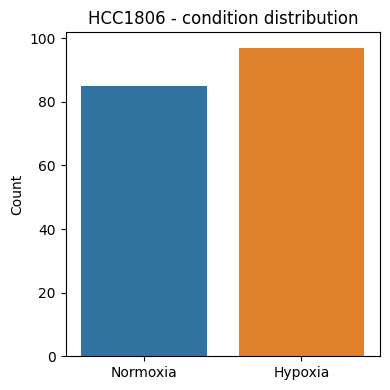

Counts:
condition
Hypoxia     97
Normoxia    85
Name: count, dtype: int64

Ratio (%):
condition
Hypoxia     53.3
Normoxia    46.7
Name: count, dtype: float64

-> classes are roughly balanced (~53/47), so NMI/ARI are directly interpretable without class-imbalance corrections.


In [6]:
plt.figure(figsize=(4, 4))

sns.countplot(
    x=hcc["condition"],
    hue=hcc["condition"],
    palette=COND_PALETTE,
    legend=False,
)
plt.title("HCC1806 - condition distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

counts = hcc["condition"].value_counts()
ratio = (counts / counts.sum() * 100).round(2)

print("Counts:")
print(counts)
print("\nRatio (%):")
print(ratio)
print("\n-> classes are roughly balanced (~53/47), so NMI/ARI are "
      "directly interpretable without class-imbalance corrections.")

### 1.x Feature selection — exploratory only (NOT applied)

The cells below explore the two standard scRNA-seq feature-selection
steps — filtering lowly detected genes and selecting highly variable
genes (HVG) — and are kept **for completeness**, to document that the
procedure was considered.

They are **not applied** to the pipeline: with ~3000 genes and ~180
cells the dataset is already small, PCA handles this dimensionality
directly, and gene filtering risks discarding biological signal with no
computational benefit. As the HVG cell shows, requesting the top 3000
genes returns *all* available genes (~3000), i.e. the selection is
effectively **inert** on this data.

These cells only compute and visualise diagnostics; **they do not modify
`hcc_gc` or any variable used downstream.**

In [7]:
# EXPLORATORY ONLY - does not modify hcc_gc or anything downstream.
# Detection rate per gene: fraction of cells where the gene is expressed.
expr_hcc = (hcc_gc > 0).mean(axis=0)
mask_expr_hcc = expr_hcc > 0.05  # would keep genes detected in >5% of cells

n_total = hcc_gc.shape[1]
n_kept  = int(mask_expr_hcc.sum())
print(f"Total genes: {n_total}")
print(f"Genes that WOULD pass the >5% detection filter: {n_kept} "
      f"({n_kept / n_total:.1%})")
print(f"Genes that WOULD be removed: {n_total - n_kept}")
print("-> filter NOT applied; pipeline keeps all genes.")

Total genes: 3000
Genes that WOULD pass the >5% detection filter: 2225 (74.2%)
Genes that WOULD be removed: 775
-> filter NOT applied; pipeline keeps all genes.


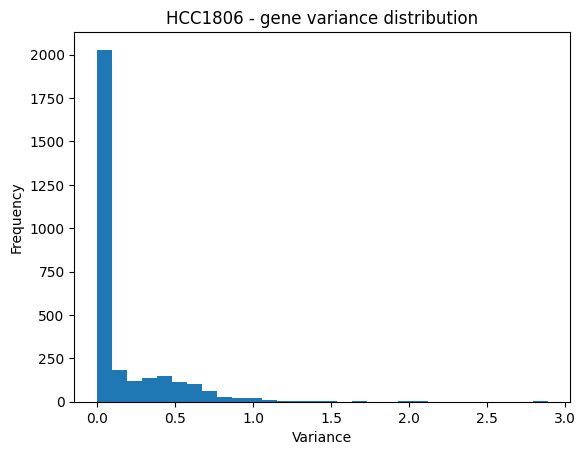

In [8]:
# EXPLORATORY - variance distribution across genes
gene_var_hcc = hcc_gc.var(axis=0)

plt.figure()
plt.hist(gene_var_hcc, bins=30)
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.title("HCC1806 - gene variance distribution")
plt.show()

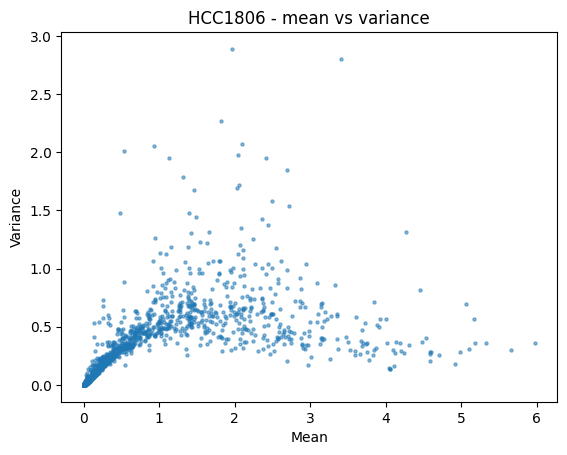

In [9]:
# EXPLORATORY - mean vs variance relationship (genes)
gene_mean_hcc = hcc_gc.mean(axis=0)
gene_var_hcc  = hcc_gc.var(axis=0)

plt.figure()
plt.scatter(gene_mean_hcc, gene_var_hcc, s=5, alpha=0.5)
plt.xlabel("Mean")
plt.ylabel("Variance")
plt.title("HCC1806 - mean vs variance")
plt.show()

In [10]:
# EXPLORATORY ONLY - does NOT create hcc_final or modify the pipeline.
# Highly Variable Gene selection via dispersion (variance / mean).
dispersion_hcc = (gene_var_hcc / gene_mean_hcc).replace([np.inf, np.nan], 0)

n_hvg = 3000
top_genes_hcc = dispersion_hcc.sort_values(ascending=False).head(n_hvg).index

print(f"Available genes: {hcc_gc.shape[1]}")
print(f"HVG requested: {n_hvg}")
print(f"HVG actually selected: {len(top_genes_hcc)}")
print("-> requested > available, so ALL genes are returned: HVG "
      "selection is inert on this dataset. Not applied to the pipeline.")

Available genes: 3000
HVG requested: 3000
HVG actually selected: 3000
-> requested > available, so ALL genes are returned: HVG selection is inert on this dataset. Not applied to the pipeline.


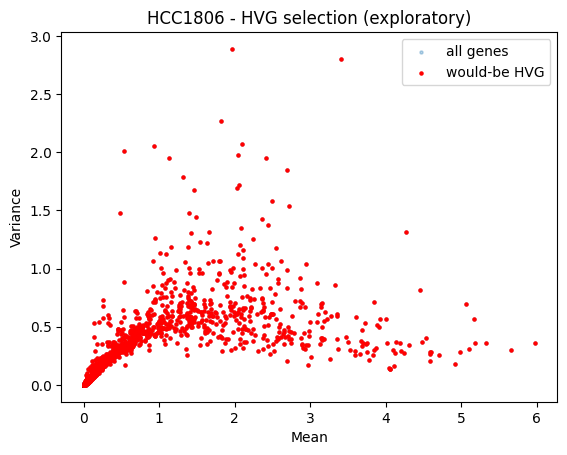

In [11]:
# EXPLORATORY - HVG (would-be) highlighted on the mean-variance plot
plt.figure()
plt.scatter(gene_mean_hcc, gene_var_hcc, s=5, alpha=0.3, label="all genes")
plt.scatter(gene_mean_hcc[top_genes_hcc], gene_var_hcc[top_genes_hcc],
            color="red", s=5, label="would-be HVG")
plt.xlabel("Mean")
plt.ylabel("Variance")
plt.title("HCC1806 - HVG selection (exploratory)")
plt.legend()
plt.show()

### 1.2 MCF7 Dataset

In [12]:
MCF_FILE = f"{DATA_DIR}/MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt"

mcf_raw = pd.read_csv(
    MCF_FILE,
    sep=r"\s+",
    index_col=0,
    quotechar='"',
)

print("Shape:", mcf_raw.shape)
print("Value dtype:", mcf_raw.dtypes.unique())
print("Range:", mcf_raw.values.min(), "-", mcf_raw.values.max())
print("Total NaN:", mcf_raw.isna().sum().sum())
mcf_raw.head()

Shape: (3000, 250)
Value dtype: [dtype('int64')]
Range: 0 - 107556
Total NaN: 0


,output.STAR.2_B3_Norm_S57_Aligned.sortedByCoord.out.bam,output.STAR.2_B4_Norm_S58_Aligned.sortedByCoord.out.bam,output.STAR.2_B5_Norm_S59_Aligned.sortedByCoord.out.bam,output.STAR.2_B6_Norm_S60_Aligned.sortedByCoord.out.bam,output.STAR.2_B7_Hypo_S79_Aligned.sortedByCoord.out.bam,output.STAR.2_B9_Hypo_S81_Aligned.sortedByCoord.out.bam,output.STAR.2_C10_Hypo_S130_Aligned.sortedByCoord.out.bam,output.STAR.2_C11_Hypo_S131_Aligned.sortedByCoord.out.bam,output.STAR.2_C1_Norm_S103_Aligned.sortedByCoord.out.bam,output.STAR.2_C2_Norm_S104_Aligned.sortedByCoord.out.bam,...,output.STAR.4_H10_Hypo_S382_Aligned.sortedByCoord.out.bam,output.STAR.4_H14_Hypo_S383_Aligned.sortedByCoord.out.bam,output.STAR.4_H1_Norm_S355_Aligned.sortedByCoord.out.bam,output.STAR.4_H3_Norm_S357_Aligned.sortedByCoord.out.bam,output.STAR.4_H4_Norm_S358_Aligned.sortedByCoord.out.bam,output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam,output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam,output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam,output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam,output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam
CYP1B1,343,131,452,27,5817,3841,9263,21543,1013,53,...,7890,4512,160,351,327,196,504,34565,20024,5953
CYP1B1-AS1,140,59,203,7,2669,1565,3866,9113,459,22,...,3647,2035,75,138,130,102,238,13717,7835,2367
CYP1A1,0,0,0,0,0,79,238,443,0,0,...,86,1654,0,0,0,1,0,11274,563,522
NDRG1,0,1,0,0,654,1263,2634,540,0,13,...,481,1052,0,0,54,243,62,1263,925,1572
DDIT4,386,289,0,288,2484,2596,1323,2044,36,204,...,3692,2410,800,1,189,266,417,4256,12733,2275


In [13]:
print("Shape:", mcf_raw.shape)

sparsity = (mcf_raw == 0).sum().sum() / mcf_raw.size
lib = mcf_raw.sum(axis=0)
print(f"Sparsity (fraction of zeros): {sparsity:.2%}")
print(f"Library size per cell -> min: {lib.min():.0f}, "
      f"median: {lib.median():.0f}, max: {lib.max():.0f}")

mcf_raw.describe()

Shape: (3000, 250)
Sparsity (fraction of zeros): 63.62%
Library size per cell -> min: 222421, median: 330296, max: 537979


,output.STAR.2_B3_Norm_S57_Aligned.sortedByCoord.out.bam,output.STAR.2_B4_Norm_S58_Aligned.sortedByCoord.out.bam,output.STAR.2_B5_Norm_S59_Aligned.sortedByCoord.out.bam,output.STAR.2_B6_Norm_S60_Aligned.sortedByCoord.out.bam,output.STAR.2_B7_Hypo_S79_Aligned.sortedByCoord.out.bam,output.STAR.2_B9_Hypo_S81_Aligned.sortedByCoord.out.bam,output.STAR.2_C10_Hypo_S130_Aligned.sortedByCoord.out.bam,output.STAR.2_C11_Hypo_S131_Aligned.sortedByCoord.out.bam,output.STAR.2_C1_Norm_S103_Aligned.sortedByCoord.out.bam,output.STAR.2_C2_Norm_S104_Aligned.sortedByCoord.out.bam,...,output.STAR.4_H10_Hypo_S382_Aligned.sortedByCoord.out.bam,output.STAR.4_H14_Hypo_S383_Aligned.sortedByCoord.out.bam,output.STAR.4_H1_Norm_S355_Aligned.sortedByCoord.out.bam,output.STAR.4_H3_Norm_S357_Aligned.sortedByCoord.out.bam,output.STAR.4_H4_Norm_S358_Aligned.sortedByCoord.out.bam,output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam,output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam,output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam,output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam,output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,74.140333,90.907000,99.089000,88.137000,110.395667,148.849000,126.422667,142.229667,91.781000,91.426333,...,144.008333,133.846000,98.699333,84.070333,101.416333,96.636667,92.344333,154.387333,125.340000,132.017667
std,345.005307,409.560228,442.980702,425.804372,822.178446,1710.088769,1351.567001,1515.496440,388.660906,376.793214,...,1349.125183,1242.320764,417.410827,406.100983,513.988262,499.224863,680.698856,1169.686762,1066.926126,1422.143351
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,24.000000,37.000000,33.000000,34.000000,38.250000,24.000000,13.000000,22.000000,37.000000,44.000000,...,33.000000,38.000000,52.250000,25.000000,33.000000,44.000000,17.000000,19.000000,21.000000,20.250000
max,8222.000000,10167.000000,11446.000000,10312.000000,30586.000000,65037.000000,52680.000000,60789.000000,9394.000000,9077.000000,...,56392.000000,50404.000000,11352.000000,8713.000000,17006.000000,16625.000000,29663.000000,34565.000000,34175.000000,57814.000000


In [14]:
# Same normalisation as HCC1806, applied symmetrically.
lib_size = mcf_raw.sum(axis=0)
assert (lib_size > 0).all(), "Some cells have zero library size"

mcf_norm = mcf_raw.div(lib_size, axis=1) * 1e4
mcf_log  = np.log1p(mcf_norm)

In [15]:
mcf = mcf_log.T

mcf["condition"] = (
    mcf.index.to_series()
    .str.extract(r"(Hypo|Norm)", expand=False)
    .replace({"Hypo": "Hypoxia", "Norm": "Normoxia"})
)

n_missing = mcf["condition"].isna().sum()
print(f"condition: {n_missing} unmatched -> "
      + ("OK" if n_missing == 0 else "CHECK REGEX"))
print("Condition values:", mcf["condition"].unique())

mcf_gc = mcf.drop(columns=["condition"])

condition: 0 unmatched -> OK
Condition values: ['Normoxia' 'Hypoxia']


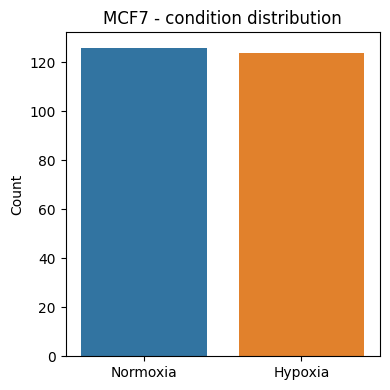

Counts:
condition
Normoxia    126
Hypoxia     124
Name: count, dtype: int64

Ratio (%):
condition
Normoxia    50.4
Hypoxia     49.6
Name: count, dtype: float64


In [16]:
plt.figure(figsize=(4, 4))

sns.countplot(
    x=mcf["condition"],
    hue=mcf["condition"],
    palette=COND_PALETTE,
    legend=False,
)
plt.title("MCF7 - condition distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

counts = mcf["condition"].value_counts()
ratio = (counts / counts.sum() * 100).round(2)

print("Counts:")
print(counts)
print("\nRatio (%):")
print(ratio)

In [17]:
# EXPLORATORY ONLY - mirror of the HCC feature-selection diagnostics.
expr_mcf = (mcf_gc > 0).mean(axis=0)
mask_expr_mcf = expr_mcf > 0.05

n_total = mcf_gc.shape[1]
n_kept  = int(mask_expr_mcf.sum())
print(f"Total genes: {n_total}")
print(f"Genes that WOULD pass the >5% detection filter: {n_kept} "
      f"({n_kept / n_total:.1%})")
print(f"Genes that WOULD be removed: {n_total - n_kept}")
print("-> filter NOT applied; pipeline keeps all genes.")

Total genes: 3000
Genes that WOULD pass the >5% detection filter: 2283 (76.1%)
Genes that WOULD be removed: 717
-> filter NOT applied; pipeline keeps all genes.


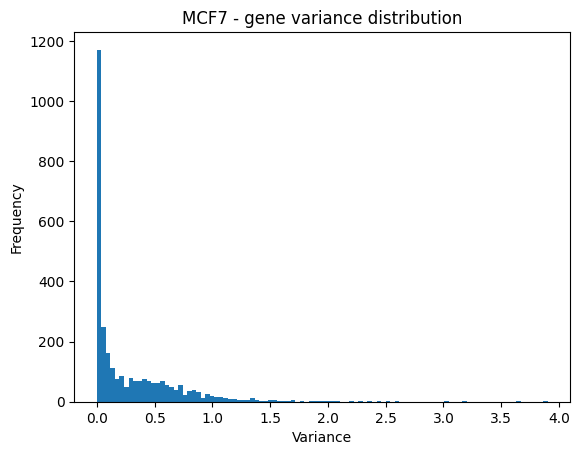

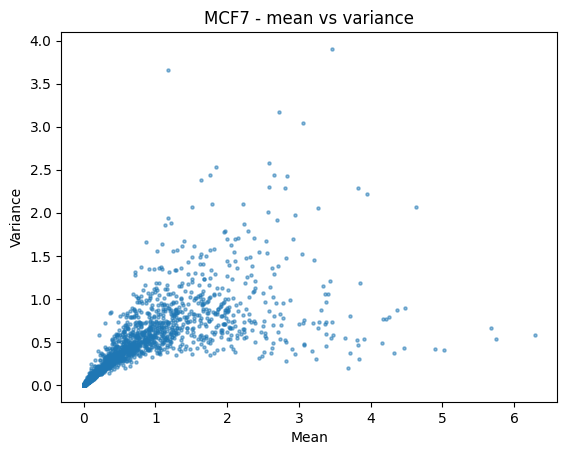

In [18]:
gene_mean_mcf = mcf_gc.mean(axis=0)
gene_var_mcf  = mcf_gc.var(axis=0)

plt.figure()
plt.hist(gene_var_mcf, bins=100)
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.title("MCF7 - gene variance distribution")
plt.show()

plt.figure()
plt.scatter(gene_mean_mcf, gene_var_mcf, s=5, alpha=0.5)
plt.xlabel("Mean")
plt.ylabel("Variance")
plt.title("MCF7 - mean vs variance")
plt.show()

Available genes: 3000
HVG requested: 3000
HVG actually selected: 3000
-> HVG selection inert on this dataset. Not applied to pipeline.


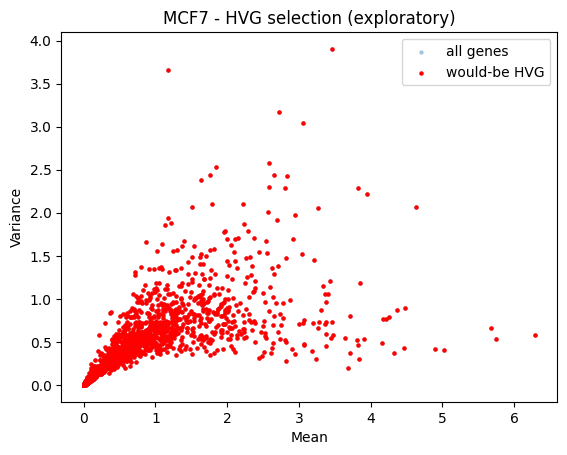

In [19]:
dispersion_mcf = (gene_var_mcf / gene_mean_mcf).replace([np.inf, np.nan], 0)

n_hvg = 3000
top_genes_mcf = dispersion_mcf.sort_values(ascending=False).head(n_hvg).index

print(f"Available genes: {mcf_gc.shape[1]}")
print(f"HVG requested: {n_hvg}")
print(f"HVG actually selected: {len(top_genes_mcf)}")
print("-> HVG selection inert on this dataset. Not applied to pipeline.")

plt.figure()
plt.scatter(gene_mean_mcf, gene_var_mcf, s=5, alpha=0.3, label="all genes")
plt.scatter(gene_mean_mcf[top_genes_mcf], gene_var_mcf[top_genes_mcf],
            color="red", s=5, label="would-be HVG")
plt.xlabel("Mean")
plt.ylabel("Variance")
plt.title("MCF7 - HVG selection (exploratory)")
plt.legend()
plt.show()

### 1.x.1 Gene co-expression (covariance) structure - exploratory only (NOT applied)

In addition to the per-gene variance / dispersion diagnostics above, we
inspect the **pairwise covariance / correlation structure** between
genes. Highly variable genes are often co-expressed in coordinated
modules, so two descriptive questions are worth documenting:

* are there **hub genes** - genes correlated with many others - that
  dominate the covariance structure?
* how much **near-redundancy** is there (genes that are almost
  duplicates of one another)?

**Method.** Correlation is computed with **Spearman** (rank) rather
than Pearson: with only ~180 cells and zero-inflated counts, Pearson
is dominated by a few extreme values and assumes linearity, whereas
Spearman is more robust to outliers and to monotone-but-nonlinear
co-expression. Spearman does **not** remove the dropout problem (many
tied zero-ranks remain), so this is a partial, honest improvement.

**No pre-filtering of genes.** The correlation is computed over **all
genes** in `hcc_gc` / `mcf_gc`. No top-variable subset is selected
before the analysis: this section does not apply any HVG / dispersion
filter, consistent with the pipeline-level decision elsewhere in
section 1.x that highly-variable-gene selection is exploratory and
not applied. Consequence to keep in mind: because low-variance and
heavily-dropout genes are included, the raw correlation structure is
noisier and the clustermaps are less crisp than they would be on a
variable-gene subset - this is the honest, unfiltered view.

> **Methodological caveat.** These correlations rest on ~180 cells and
> zero-inflated scRNA-seq data, computed over all genes. The "hub"
> degree is a **rough qualitative indicator, not a precise network
> statistic**. It is reported for completeness; PCA in section 2
> already absorbs this covariance, so no gene is removed from the
> pipeline.

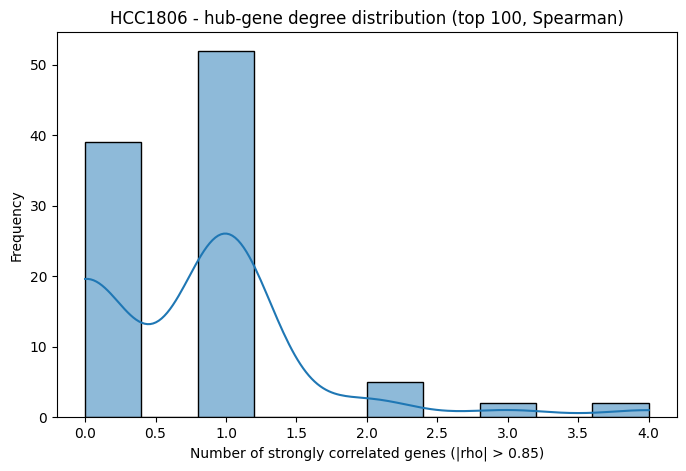

In [20]:
# EXPLORATORY ONLY - HCC1806 co-expression hubs.
# Correlation over ALL genes (no top-variable pre-filter), Spearman.
# This does NOT modify hcc_gc or anything used downstream.
HUB_RHO = 0.85   # |Spearman rho| threshold defining a "strong" edge

corr_matrix_hcc = hcc_gc.corr(method="spearman")

# Degree = number of OTHER genes a gene is strongly correlated with.
degree_hcc = (corr_matrix_hcc.abs() > HUB_RHO).sum(axis=1) - 1
top_hubs_hcc = degree_hcc.sort_values(ascending=False).head(100)
hub_genes_hcc = top_hubs_hcc.index

plt.figure(figsize=(8, 5))
sns.histplot(top_hubs_hcc, bins=10, kde=True, color=PALETTE[0])
plt.title("HCC1806 - hub-gene degree distribution (top 100, Spearman)")
plt.xlabel(f"Number of strongly correlated genes (|rho| > {HUB_RHO})")
plt.ylabel("Frequency")
plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


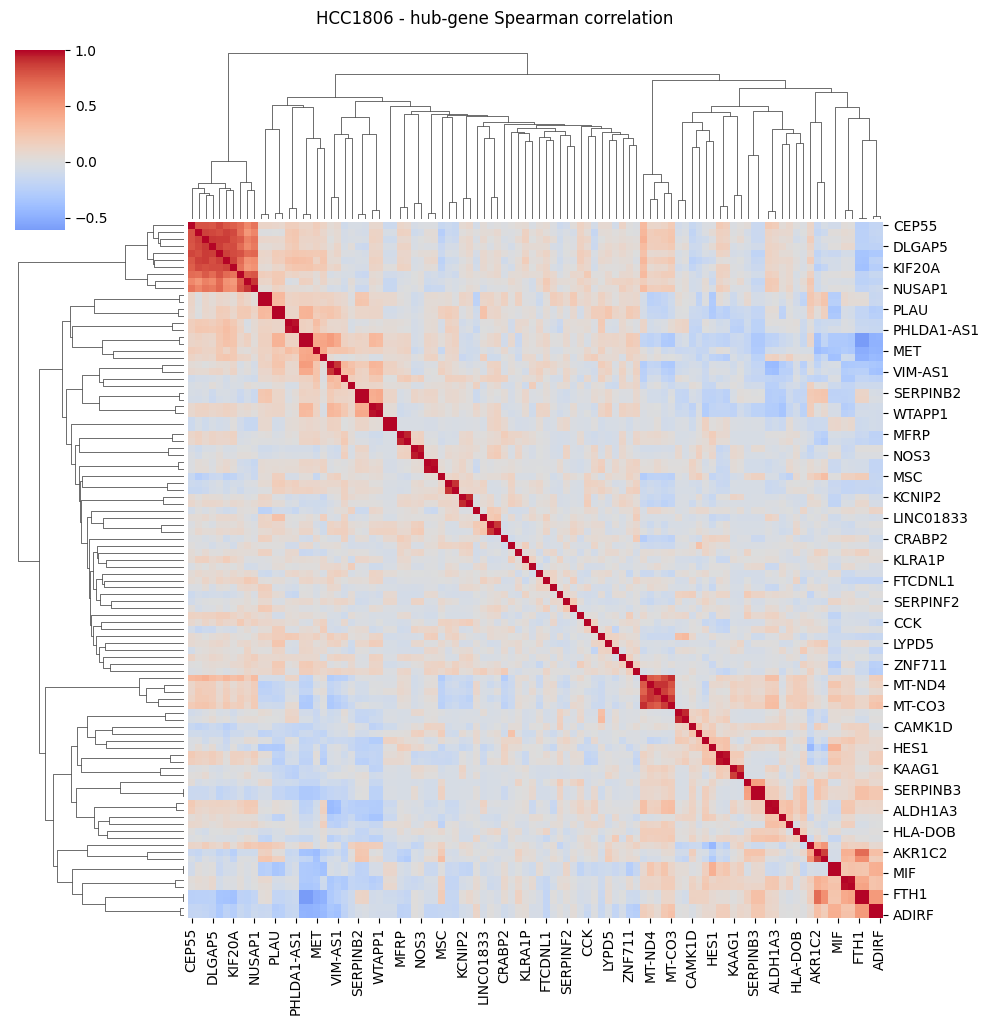

In [21]:
# EXPLORATORY - clustered Spearman-correlation map of HCC1806 hub genes
corr_hubs_hcc = corr_matrix_hcc.loc[hub_genes_hcc, hub_genes_hcc].head(200)
g = sns.clustermap(
    corr_hubs_hcc,
    cmap="coolwarm",
    center=0,
    figsize=(10, 10),
)
g.fig.suptitle("HCC1806 - hub-gene Spearman correlation", y=1.02)
plt.show()


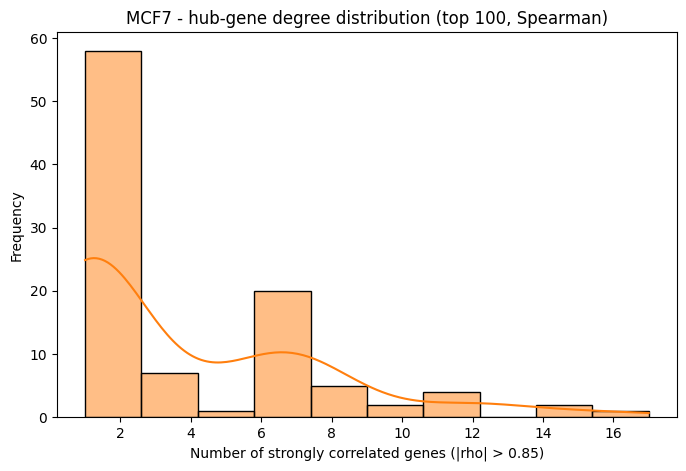

In [22]:
# EXPLORATORY ONLY - MCF7 co-expression hubs (mirror of HCC, Spearman).
# Correlation over ALL genes (no top-variable pre-filter).
corr_matrix_mcf = mcf_gc.corr(method="spearman")

degree_mcf = (corr_matrix_mcf.abs() > HUB_RHO).sum(axis=1) - 1
top_hubs_mcf = degree_mcf.sort_values(ascending=False).head(100)
hub_genes_mcf = top_hubs_mcf.index

plt.figure(figsize=(8, 5))
sns.histplot(top_hubs_mcf, bins=10, kde=True, color=PALETTE[1])
plt.title("MCF7 - hub-gene degree distribution (top 100, Spearman)")
plt.xlabel(f"Number of strongly correlated genes (|rho| > {HUB_RHO})")
plt.ylabel("Frequency")
plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


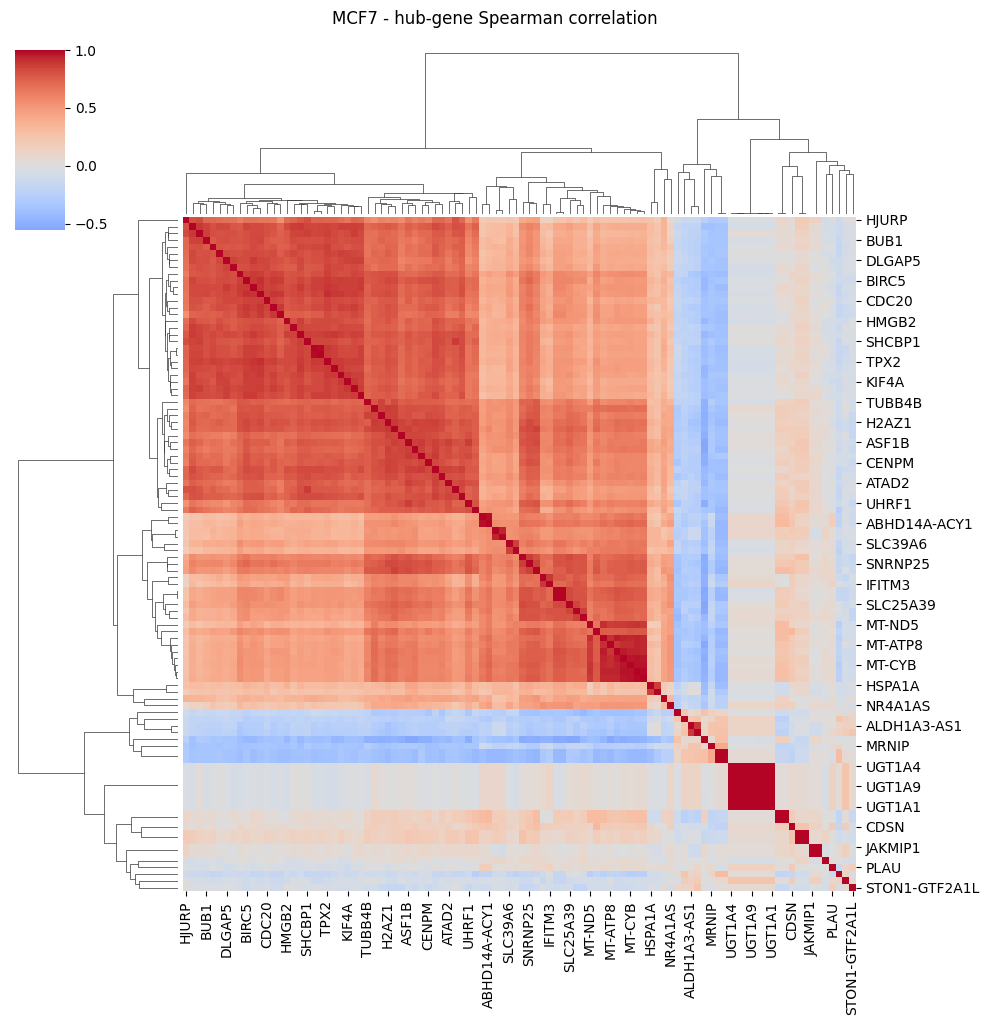

In [23]:
# EXPLORATORY - clustered Spearman-correlation map of MCF7 hub genes
corr_hubs_mcf = corr_matrix_mcf.loc[hub_genes_mcf, hub_genes_mcf].head(200)
g = sns.clustermap(
    corr_hubs_mcf,
    cmap="coolwarm",
    center=0,
    figsize=(10, 10),
)
g.fig.suptitle("MCF7 - hub-gene Spearman correlation", y=1.02)
plt.show()


In [24]:
# EXPLORATORY ONLY - how much NEAR-REDUNDANCY is there (|rho| > 0.95)?
# Purpose: quantify redundancy for completeness. We do NOT pick which
# gene to drop (that choice would be arbitrary and is not needed - the
# pipeline keeps all genes and PCA absorbs the covariance). We only
# count, in an order-independent way, how many genes have at least one
# near-duplicate, and how many redundancy groups they form.
# Computed over ALL genes (no top-variable pre-filter).
REDUNDANCY_RHO = 0.95


def redundancy_summary(df, threshold=REDUNDANCY_RHO):
    """Order-independent redundancy quantification.

    A gene is 'redundant' if it has |Spearman rho| > threshold with at
    least one OTHER gene. We also count connected groups of mutually
    near-duplicate genes (connected components of the redundancy graph).
    Returns a dict of counts only - no gene list, no drop decision.
    """
    rho = df.corr(method="spearman").abs().to_numpy(copy=True)
    np.fill_diagonal(rho, 0.0)                 # ignore self-correlation

    adj = rho > threshold                      # symmetric adjacency matrix
    is_redundant = adj.any(axis=1)             # gene tied to >=1 other gene
    n_redundant = int(is_redundant.sum())

    # Count connected components among the redundant genes (BFS).
    n_genes = adj.shape[0]
    seen = np.zeros(n_genes, dtype=bool)
    n_groups = 0
    for start in range(n_genes):
        if seen[start] or not is_redundant[start]:
            continue
        n_groups += 1
        stack = [start]
        seen[start] = True
        while stack:
            u = stack.pop()
            for v in np.where(adj[u])[0]:
                if not seen[v]:
                    seen[v] = True
                    stack.append(v)

    return {
        "n_total": n_genes,
        "n_redundant": n_redundant,
        "n_groups": n_groups,
        "pct_redundant": 100.0 * n_redundant / n_genes,
    }


red_hcc = redundancy_summary(hcc_gc, threshold=REDUNDANCY_RHO)
red_mcf = redundancy_summary(mcf_gc, threshold=REDUNDANCY_RHO)

for name, r in [("HCC1806", red_hcc), ("MCF7", red_mcf)]:
    print(f"{name}: {r['n_redundant']}/{r['n_total']} genes "
          f"({r['pct_redundant']:.2f}%) have a near-duplicate "
          f"(|rho| > {REDUNDANCY_RHO}), forming "
          f"{r['n_groups']} redundancy group(s).")
print("-> redundancy is only quantified, not removed; PCA already "
      "absorbs this covariance, so the pipeline keeps all genes.")


HCC1806: 32/3000 genes (1.07%) have a near-duplicate (|rho| > 0.95), forming 16 redundancy group(s).
MCF7: 55/3000 genes (1.83%) have a near-duplicate (|rho| > 0.95), forming 23 redundancy group(s).
-> redundancy is only quantified, not removed; PCA already absorbs this covariance, so the pipeline keeps all genes.


### 1.x.2 Over-representation analysis (ORA) of the hub genes

The covariance clustermaps above suggest, by eye, that the dominant
hub modules look more like proliferation genes than hypoxia genes.
"By eye" is not a result. Here we test the hypoxia question
**quantitatively** with **over-representation analysis (ORA)**: a
Fisher exact test asks whether the overlap between our hub-gene list
and the hypoxia signature is larger than expected by chance, with
Benjamini-Hochberg FDR correction. The hub list here is defined from
the Spearman correlation over **all genes** (no top-variable filter),
with the |rho| > 0.85 degree threshold set in section 1.x.1.

ORA — not GSEA — is the statistically appropriate method here, because
the hub list is a **discrete set** (a gene is either among the
top-degree hubs or not); there is no continuous per-gene ranking to
feed GSEA. This follows the ORA vs GSEA distinction in the course
document.

**Gene set provenance — deliberately strict.** This section tests the
hub genes against the **official Buffa hypoxia metagene**, loaded from
the MSigDB `.gmt`. Earlier drafts used a small hypoxia subset
transcribed from the PDF and a hand-built cell-cycle panel; those were
replaced because a reconstruction is weaker and less reproducible than
the published signature. The cell **has no fallback**: if the official
file is missing it stops with a clear error, so the result can only
ever come from the real signature.

Scope note: with Buffa only, this ORA answers one focused question —
*are the hubs enriched for the hypoxia programme?* The
proliferation / cell-cycle comparison is **not** done here; it is
covered by the online `gseapy`/Enrichr cell below, which queries the
full MSigDB Hallmark and GO libraries (including G2M / E2F / mitotic
terms).

This remains an exploratory diagnostic: it interprets the covariance
structure but does not change the pipeline.


In [25]:
# Gene set: Buffa hypoxia metagene - loaded from the OFFICIAL MSigDB file.
# No hardcoded gene lists, no memory-reconstructed signatures.
#
# WHAT YOU MUST DOWNLOAD (once), from the link in the course PDF (sec 3.4):
#   BUFFA_HYPOXIA_METAGENE  ->  save the .gmt next to this notebook.
#   MSigDB: https://www.gsea-msigdb.org/gsea/msigdb/human/geneset/BUFFA_HYPOXIA_METAGENE.html
#   (MSigDB needs a free login; the .gmt download cannot be automated here.)
#
# Adjust BUFFA_GMT_PATH to the file name/location you saved.
from pathlib import Path

BUFFA_GMT_PATH = Path("BUFFA_HYPOXIA_METAGENE.v2026.1.Hs.gmt")


def parse_gmt(path):
    """Parse a standard MSigDB .gmt file.

    Each line is tab-separated: set_name, description, gene1, gene2, ...
    Returns a dict {set_name: set(genes)}.
    """
    path = Path(path)
    if not path.exists():
        msg = (
            "Gene-set file not found: " + str(path.resolve()) + "\n"
            "Download BUFFA_HYPOXIA_METAGENE.gmt from MSigDB (link in the "
            "course PDF, section 3.4) and place it there. This cell has NO "
            "fallback by design: the enrichment must run against the "
            "official signature, not a reconstruction."
        )
        raise FileNotFoundError(msg)
    sets = {}
    with open(path) as fh:
        for line in fh:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            name, _desc, *genes = parts
            sets[name] = {g.strip() for g in genes if g.strip()}
    if not sets:
        raise ValueError(
            "No gene sets parsed from " + str(path) + " - is it a valid .gmt?"
        )
    return sets


_buffa_raw = parse_gmt(BUFFA_GMT_PATH)

# The .gmt normally contains the single Buffa set; pick it explicitly.
_buffa_key = next(
    (k for k in _buffa_raw if "BUFFA" in k.upper()),
    next(iter(_buffa_raw)),
)
GENE_SETS = {_buffa_key: _buffa_raw[_buffa_key]}

print("Loaded official gene set(s) from", BUFFA_GMT_PATH.name)
for k, v in GENE_SETS.items():
    print("  " + k + ": " + str(len(v)) + " genes")
print("(Expected ~50 genes for the Buffa metagene.)")


Loaded official gene set(s) from BUFFA_HYPOXIA_METAGENE.v2026.1.Hs.gmt
  BUFFA_HYPOXIA_METAGENE: 50 genes
(Expected ~50 genes for the Buffa metagene.)


In [26]:
from scipy.stats import fisher_exact


def _bh_fdr(pvals):
    """Benjamini-Hochberg FDR, no statsmodels dependency."""
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order] * n / (np.arange(n) + 1)
    # enforce monotonicity from the largest p downward
    ranked[::-1] = np.minimum.accumulate(ranked[::-1])
    out = np.empty(n)
    out[order] = np.clip(ranked, 0, 1)
    return out


def ora_offline(hit_genes, background_genes, gene_sets):
    """Fisher exact ORA of `hit_genes` against each set in `gene_sets`,
    restricted to `background_genes` (the genes actually measured).
    BH-FDR across sets. Pure-Python."""
    bg = set(map(str, background_genes))
    hits = set(map(str, hit_genes)) & bg            # only measured genes
    rows = []
    for name, gs in gene_sets.items():
        gs_bg = gs & bg                              # set restricted to bg
        if not gs_bg:
            continue
        a = len(hits & gs_bg)                        # hit & in set
        b = len(hits) - a                            # hit & not in set
        c = len(gs_bg) - a                           # not hit & in set
        d = len(bg) - a - b - c                      # neither
        odds, p = fisher_exact([[a, b], [c, d]], alternative="greater")
        rows.append({
            "gene_set": name, "overlap": a, "set_size_in_bg": len(gs_bg),
            "n_hits": len(hits), "odds_ratio": odds, "p_value": p,
        })
    res = pd.DataFrame(rows)
    if len(res):
        res["FDR_BH"] = _bh_fdr(res["p_value"].values)
        res = res.sort_values("p_value").reset_index(drop=True)
    return res


# Background = genes actually measured in each cell line.
bg_hcc = hcc_gc.columns
bg_mcf = mcf_gc.columns

print("=== ORA (Buffa signature) - HCC1806 hub genes ===")
ora_hcc_off = ora_offline(hub_genes_hcc, bg_hcc, GENE_SETS)
display(ora_hcc_off.round(4))

print("=== ORA (Buffa signature) - MCF7 hub genes ===")
ora_mcf_off = ora_offline(hub_genes_mcf, bg_mcf, GENE_SETS)
display(ora_mcf_off.round(4))


=== ORA (Buffa signature) - HCC1806 hub genes ===


,gene_set,overlap,set_size_in_bg,n_hits,odds_ratio,p_value,FDR_BH
0,BUFFA_HYPOXIA_METAGENE,2,21,100,3.0945,0.1536,0.1536


=== ORA (Buffa signature) - MCF7 hub genes ===


,gene_set,overlap,set_size_in_bg,n_hits,odds_ratio,p_value,FDR_BH
0,BUFFA_HYPOXIA_METAGENE,3,24,100,4.2401,0.0438,0.0438


In [ ]:
# ONLINE ORA via gseapy/Enrichr - full official libraries.
# NOTE: needs network access (Enrichr). If it fails,
# the offline ORA above still gives a usable, transparent answer.
try:
    import gseapy as gp

    ENRICHR_LIBS = ["MSigDB_Hallmark_2020", "GO_Biological_Process_2021"]

    def ora_online(hit_genes, libs, tag):
        enr = gp.enrichr(
            gene_list=list(map(str, hit_genes)),
            gene_sets=libs,
            outdir=None,
        )
        r = enr.results.sort_values("Adjusted P-value")
        cols = ["Gene_set", "Term", "Overlap",
                "P-value", "Adjusted P-value", "Genes"]
        print(f"=== ONLINE ORA - {tag} (top 10 by adj p) ===")
        display(r[cols].head(10))
        return r

    ora_hcc_on = ora_online(hub_genes_hcc, ENRICHR_LIBS, "HCC1806 hubs")
    ora_mcf_on = ora_online(hub_genes_mcf, ENRICHR_LIBS, "MCF7 hubs")

except Exception as e:
    print("Online ORA skipped (gseapy/Enrichr unavailable):")
    print(f"  {type(e).__name__}: {e}")
    print("-> rely on the offline ORA above; install gseapy and ensure "
          "network access to reproduce the full-library result.")


=== ONLINE ORA - HCC1806 hubs (top 10 by adj p) ===


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Genes
34,GO_Biological_Process_2021,negative regulation of peptidase activity (GO:...,5/63,0.000016,0.007251,SERPINB3;SERPINB10;SERPINB11;SERPINB2;SERPINF2
33,GO_Biological_Process_2021,negative regulation of endopeptidase activity ...,5/63,0.000016,0.007251,SERPINB3;SERPINB10;SERPINB11;SERPINB2;SERPINF2
35,GO_Biological_Process_2021,regulation of endopeptidase activity (GO:0052548),5/71,0.000028,0.008676,SERPINB3;SERPINB10;SERPINB11;SERPINB2;SERPINF2
37,GO_Biological_Process_2021,fibrinolysis (GO:0042730),3/15,0.000053,0.009710,SERPINB2;PLAU;SERPINF2
36,GO_Biological_Process_2021,negative regulation of blood coagulation (GO:0...,4/40,0.000047,0.009710,SERPINB2;PLAU;NOS3;SERPINF2
0,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,6/200,0.000507,0.016732,SERPINB2;PLAU;HES1;MSC;PHLDA1;SQSTM1
38,GO_Biological_Process_2021,mitotic sister chromatid segregation (GO:0000070),5/102,0.000160,0.024558,CCNB1;NUSAP1;KLHL22;DLGAP5;CEP55
39,GO_Biological_Process_2021,negative regulation of macrophage chemotaxis (...,2/5,0.000245,0.032176,SLAMF8;MIF
1,MSigDB_Hallmark_2020,G2-M Checkpoint,5/200,0.003324,0.036562,CDC20;CCNB2;TPX2;NUSAP1;AURKB
2,MSigDB_Hallmark_2020,E2F Targets,5/200,0.003324,0.036562,CDC20;CCNB2;CDCA3;DLGAP5;AURKB


=== ONLINE ORA - MCF7 hubs (top 10 by adj p) ===


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Genes
0,MSigDB_Hallmark_2020,E2F Targets,25/200,2.720899e-28,7.346426e-27,TOP2A;CDCA3;HMGB2;MKI67;AURKB;CDC20;CCNB2;PTTG...
1,MSigDB_Hallmark_2020,G2-M Checkpoint,22/200,1.144881e-23,1.545589e-22,TOP2A;H2AZ1;DTYMK;TROAP;PLK1;MKI67;AURKB;CDC20...
27,GO_Biological_Process_2021,microtubule cytoskeleton organization involved...,15/128,8.539928e-17,6.251227e-14,PLK1;ZWINT;AURKB;CDC20;CCNB1;CENPF;KIF4A;STMN1...
29,GO_Biological_Process_2021,flavonoid glucuronidation (GO:0052696),7/9,2.251781e-15,5.494345e-13,UGT1A10;UGT1A1;UGT1A4;UGT1A9;UGT1A8;UGT1A7;UGT1A6
28,GO_Biological_Process_2021,mitotic spindle organization (GO:0007052),15/157,1.914360e-15,5.494345e-13,PLK1;ZWINT;AURKB;CDC20;TPX2;CCNB1;CENPF;PRC1;K...
30,GO_Biological_Process_2021,xenobiotic glucuronidation (GO:0052697),7/11,2.047505e-14,3.746934e-12,UGT1A10;UGT1A1;UGT1A4;UGT1A9;UGT1A8;UGT1A7;UGT1A6
2,MSigDB_Hallmark_2020,Mitotic Spindle,13/199,2.105412e-11,1.894871e-10,TOP2A;PLK1;CCNB2;TPX2;CENPF;RACGAP1;PRC1;KIF4A...
31,GO_Biological_Process_2021,cellular glucuronidation (GO:0052695),7/19,3.026426e-12,4.430687e-10,UGT1A10;UGT1A1;UGT1A4;UGT1A9;UGT1A8;UGT1A7;UGT1A6
32,GO_Biological_Process_2021,glucuronate metabolic process (GO:0019585),6/15,6.475646e-11,7.900288e-09,UGT1A10;UGT1A1;UGT1A4;UGT1A9;UGT1A7;UGT1A6
33,GO_Biological_Process_2021,mitotic sister chromatid segregation (GO:0000070),9/102,2.111237e-09,2.207751e-07,CCNB1;SPAG5;PRC1;PLK1;NCAPG2;NUSAP1;KIF2C;ZWIN...


**How to read this.** For each gene set, ORA reports the overlap with
the hub list, a Fisher odds ratio, a raw p-value, and the BH-corrected
FDR. A set is enriched if the FDR is small (commonly < 0.05) **and**
the overlap is non-trivial.

**Results (hubs from all-gene Spearman correlation, |rho| > 0.85).**

*Offline ORA - Buffa hypoxia metagene.* The hubs show **no significant
hypoxia enrichment in HCC1806** (overlap 2/21, OR ≈ 3.1, p ≈ 0.15) and
only a **weak, borderline signal in MCF7** (overlap 3/24, OR ≈ 4.2,
p ≈ 0.044). The MCF7 value sits just below the 0.05 line on only three
genes, so it is fragile - not evidence that the hubs *are* the hypoxia
programme. The sanity-check cell confirmed Buffa genes are genuinely
present in the background (~42-48% coverage, canonical hypoxia markers
found), so this weak result is real, not a naming/coverage artefact.

*Online ORA - Hallmark / GO.* Proliferation dominates. In **MCF7** the
top terms are overwhelmingly cell-cycle: E2F Targets (FDR ≈ 7e-27,
25/200) and G2-M Checkpoint (FDR ≈ 2e-22, 22/200), followed by
mitotic-spindle / microtubule terms, with UGT1A glucuronidation terms
secondary. In **HCC1806** the signal is weaker and different:
peptidase/endopeptidase regulation (SERPINB family), fibrinolysis and
coagulation, and TNF-α signalling (FDR ≈ 0.007-0.03), with cell-cycle
terms (G2-M, E2F) present but lower (FDR ≈ 0.04). **Hallmark Hypoxia
is not among the enriched terms in either cell line.**

**Interpretation.** The strongly co-expressed hub modules are driven by
**proliferation / cell-cycle**, not by hypoxia - robustly and very
strongly in MCF7, more weakly and alongside protease/coagulation
programmes in HCC1806. Any hypoxia signal in the hubs is weak and
**threshold-sensitive**: it was absent at |rho| > 0.9 and only appears
as a borderline MCF7 result at the more permissive |rho| > 0.85. That
sensitivity is itself the honest finding - the proliferation signal is
stable across thresholds, the hypoxia signal is not. Hypoxia is
therefore not what organises the gene-gene covariance, even though it
remains the axis that separates *samples* elsewhere in the notebook.

### 1.x.3 Conclusion - hypoxia is not encoded in the co-expression structure

Bringing the covariance analysis together: across both cell lines, the
genes that are strongly co-expressed (the hub modules) are organised by
**proliferation / cell-cycle**, not by hypoxia. This is the robust,
reproducible finding - the cell-cycle signal is overwhelming in MCF7
(E2F Targets FDR ≈ 7e-27, G2-M Checkpoint FDR ≈ 2e-22) and present,
though weaker and mixed with protease/coagulation programmes, in
HCC1806. Hallmark Hypoxia is **not** among the enriched terms in either
line.

The hypoxia programme, by contrast, leaves **no stable footprint in the
gene-gene correlation structure**. Against the official Buffa metagene
the hubs show no enrichment in HCC1806 (p ≈ 0.15) and only a weak,
borderline overlap in MCF7 (3/24 genes, p ≈ 0.044) that appears only at
the more permissive |rho| > 0.85 threshold and vanishes at |rho| > 0.9.
A signal that depends on the threshold and rests on three genes is not
a co-expression module - it is noise at the significance boundary.

We can therefore reasonably infer that **hypoxia is not recoverable
from correlation structure alone in this data**: it does not act as a
coordinated co-expression module the way the cell-cycle programme does.
This is not a negative or failed result - it is biologically coherent.
Hypoxia remains a real and important axis in this dataset; elsewhere in
this notebook it is what separates the samples. The point is more
specific: hypoxia here behaves as a *condition-level* effect that
shifts global expression between Normoxia and Hypoxia, rather than as a
tight set of mutually co-regulated genes that covariance analysis can
isolate. Methods that model the condition directly (the differential
and dimensionality-reduction sections) capture it; unsupervised
gene-gene correlation does not, and should not be expected to.

*Caveats.* ~180 cells, zero-inflation, no variable-gene pre-filter, and
a threshold-dependent hub definition all make the covariance structure
noisy. The strong cell-cycle signal is partly the known effect of cells
captured in different cell-cycle phases. UGT1A-family enrichment partly
reflects genomic co-location of tandem genes rather than regulation.
These do not change the conclusion but bound how strongly it can be
stated.

## 2. Dimensionality Reduction

The full log-normalised matrices (`hcc_gc`, `mcf_gc`) are standardised
(zero mean, unit variance per gene) and reduced with PCA. PCA is then
used as the input space for clustering; t-SNE and UMAP are used **for
visualisation only** (see §3).

### 2.1 Principal Component Analysis (PCA)

In [28]:
# Standardise per gene. NOTE: a SEPARATE scaler is fit on each dataset
# (no shared state, no leakage). Only the training data are available
# here; if a test set were used, the scaler fit on train must be reused.
scaler_hcc = StandardScaler()
scaler_mcf = StandardScaler()

hcc_scaled = scaler_hcc.fit_transform(hcc_gc)
mcf_scaled = scaler_mcf.fit_transform(mcf_gc)

# Full PCA to inspect the variance spectrum
pca_full_hcc = PCA(random_state=RANDOM_STATE).fit(hcc_scaled)
pca_full_mcf = PCA(random_state=RANDOM_STATE).fit(mcf_scaled)

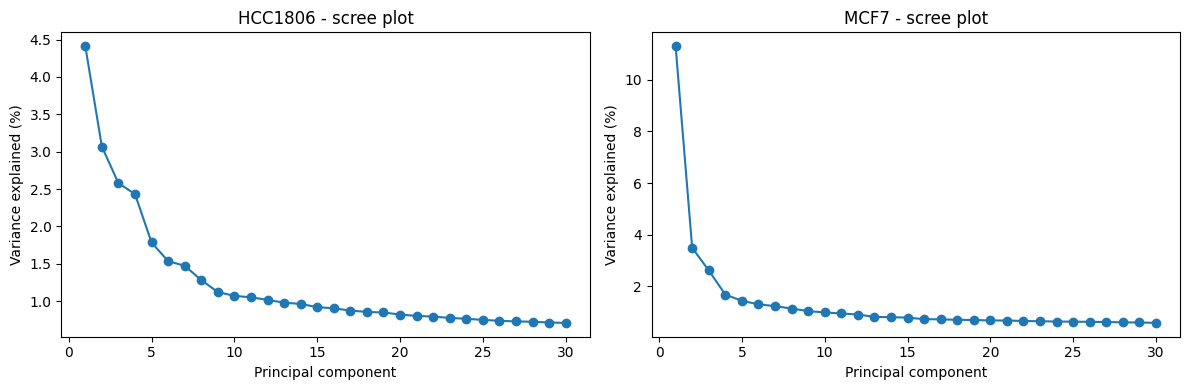

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, 31),
             pca_full_hcc.explained_variance_ratio_[:30] * 100, "o-")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("HCC1806 - scree plot")

axes[1].plot(range(1, 31),
             pca_full_mcf.explained_variance_ratio_[:30] * 100, "o-")
axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Variance explained (%)")
axes[1].set_title("MCF7 - scree plot")

plt.tight_layout()
plt.show()

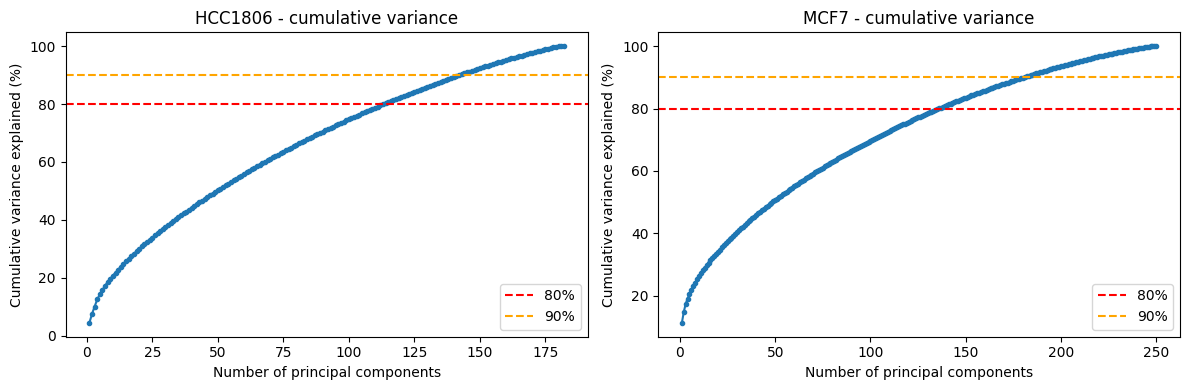

HCC1806: 114 PCs for 80% variance, 143 PCs for 90%
MCF7: 136 PCs for 80% variance, 181 PCs for 90%


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cumvar_hcc = np.cumsum(pca_full_hcc.explained_variance_ratio_) * 100
axes[0].plot(range(1, len(cumvar_hcc) + 1), cumvar_hcc, "o-", markersize=3)
axes[0].axhline(80, color="red", linestyle="--", label="80%")
axes[0].axhline(90, color="orange", linestyle="--", label="90%")
axes[0].set_xlabel("Number of principal components")
axes[0].set_ylabel("Cumulative variance explained (%)")
axes[0].set_title("HCC1806 - cumulative variance")
axes[0].legend()

cumvar_mcf = np.cumsum(pca_full_mcf.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumvar_mcf) + 1), cumvar_mcf, "o-", markersize=3)
axes[1].axhline(80, color="red", linestyle="--", label="80%")
axes[1].axhline(90, color="orange", linestyle="--", label="90%")
axes[1].set_xlabel("Number of principal components")
axes[1].set_ylabel("Cumulative variance explained (%)")
axes[1].set_title("MCF7 - cumulative variance")
axes[1].legend()

plt.tight_layout()
plt.show()

for name, cumvar in [("HCC1806", cumvar_hcc), ("MCF7", cumvar_mcf)]:
    pc80 = np.argmax(cumvar >= 80) + 1
    pc90 = np.argmax(cumvar >= 90) + 1
    print(f"{name}: {pc80} PCs for 80% variance, {pc90} PCs for 90%")

**Choice of number of components.** Reaching 80–90% cumulative
variance requires >100 PCs, which would defeat the purpose of dimension
reduction and mostly capture single-cell technical noise. We instead
keep **60 PCs** as a pragmatic compromise: it captures the dominant
structure (~54% of variance) while strongly denoising the data before
clustering. This is a deliberate choice, not a variance-threshold
choice, and is stated explicitly for the discussion.

In [31]:
N_PCS = 60

pca_hcc = PCA(n_components=N_PCS, random_state=RANDOM_STATE)
hcc_pca = pca_hcc.fit_transform(hcc_scaled)

pca_mcf = PCA(n_components=N_PCS, random_state=RANDOM_STATE)
mcf_pca = pca_mcf.fit_transform(mcf_scaled)

print(f"HCC1806 - variance explained by {N_PCS} PCs: "
      f"{pca_hcc.explained_variance_ratio_.sum():.4f}")
print(f"MCF7   - variance explained by {N_PCS} PCs: "
      f"{pca_mcf.explained_variance_ratio_.sum():.4f}")

HCC1806 - variance explained by 60 PCs: 0.5499
MCF7   - variance explained by 60 PCs: 0.5460


**Diagnostic - sensitivity of HCC1806 clustering to the number of
PCs.** K-means on the 60-PC PCA space recovers the condition structure
almost perfectly for MCF7 but fails for HCC1806 (NMI ~ 0.02). Before
interpreting this as genuine non-linear structure, we test whether it is
an artefact of using too many noisy components on a small dataset (182
cells), by scanning K-means (k=2) over an increasing number of PCs.
Result: HCC1806 stays at NMI ~ 0 for *every* number of PCs (2 to 60),
ruling out a dimensionality artefact and confirming the signal is not
linearly separable.

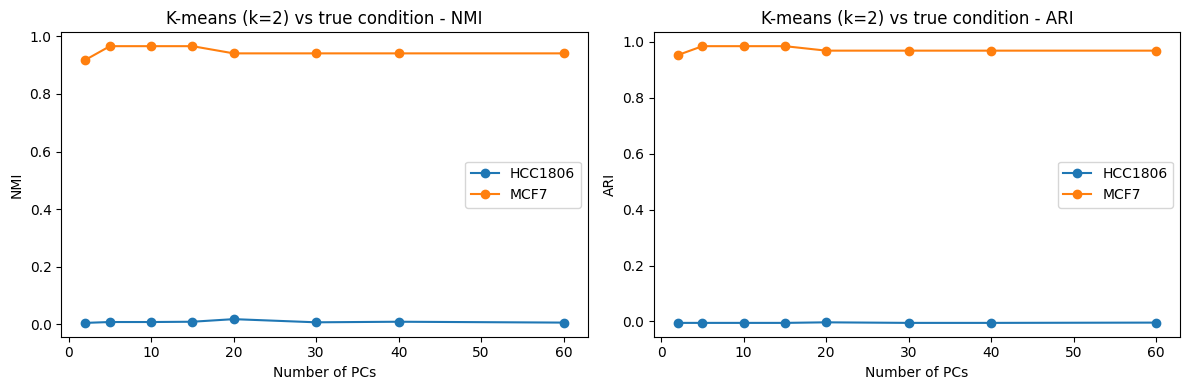

            NMI            ARI       
dataset HCC1806   MCF7 HCC1806   MCF7
n_pcs                                
2         0.005  0.918  -0.005  0.952
5         0.008  0.966  -0.005  0.984
10        0.008  0.966  -0.005  0.984
15        0.009  0.966  -0.005  0.984
20        0.018  0.941  -0.003  0.968
30        0.007  0.941  -0.005  0.968
40        0.009  0.941  -0.005  0.968
60        0.006  0.941  -0.004  0.968


In [32]:
# Diagnostic: does HCC1806 PCA-clustering improve with FEWER PCs?
# (reuses pca_full_hcc / pca_full_mcf fitted above in 2.1)
n_pcs_grid = [2, 5, 10, 15, 20, 30, 40, 60]
hcc_pca_all = pca_full_hcc.transform(hcc_scaled)
mcf_pca_all = pca_full_mcf.transform(mcf_scaled)

rows = []
for n in n_pcs_grid:
    for name, X_all, cond in [
        ("HCC1806", hcc_pca_all, hcc["condition"].values),
        ("MCF7",    mcf_pca_all, mcf["condition"].values),
    ]:
        km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
        lab = km.fit_predict(X_all[:, :n])
        rows.append({
            "dataset": name, "n_pcs": n,
            "NMI": round(normalized_mutual_info_score(cond, lab), 3),
            "ARI": round(adjusted_rand_score(cond, lab), 3),
        })
pc_scan = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, metric in enumerate(["NMI", "ARI"]):
    for j, name in enumerate(["HCC1806", "MCF7"]):
        sub = pc_scan[pc_scan["dataset"] == name]
        ax[i].plot(sub["n_pcs"], sub[metric], "o-",
                   color=PALETTE[j], label=name)
    ax[i].set_xlabel("Number of PCs")
    ax[i].set_ylabel(metric)
    ax[i].set_title(f"K-means (k=2) vs true condition - {metric}")
    ax[i].legend()
plt.tight_layout()
plt.show()

print(pc_scan.pivot(index="n_pcs", columns="dataset",
                    values=["NMI", "ARI"]))

### 2.2 t-SNE visualization

In [33]:
tsne_hcc = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
hcc_tsne = tsne_hcc.fit_transform(hcc_pca)

tsne_mcf = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
mcf_tsne = tsne_mcf.fit_transform(mcf_pca)

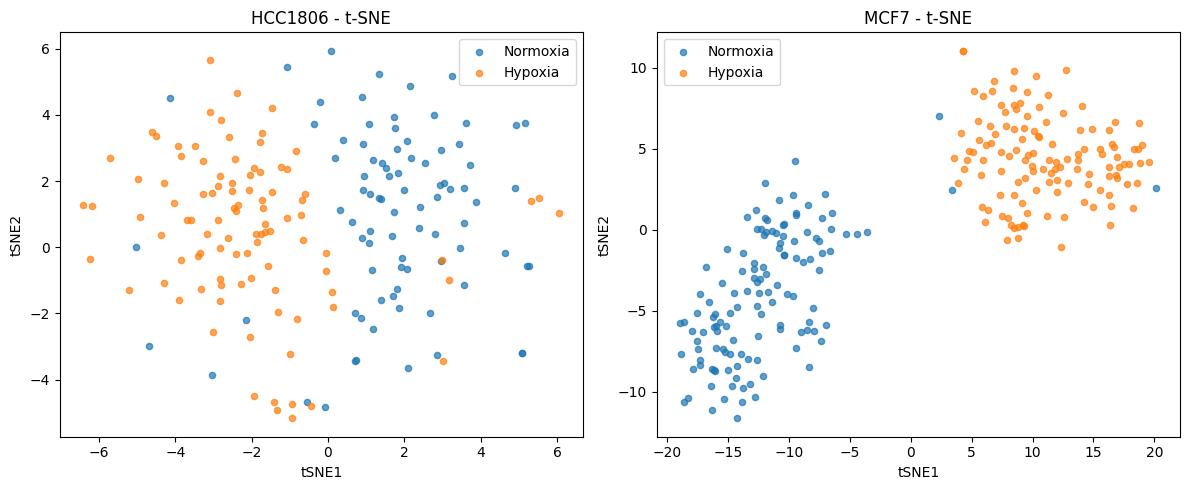

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, labels, title in zip(
    axes,
    [hcc_tsne, mcf_tsne],
    [hcc["condition"], mcf["condition"]],
    ["HCC1806 - t-SNE", "MCF7 - t-SNE"],
):
    for cond, color in zip(["Normoxia", "Hypoxia"], [PALETTE[0], PALETTE[1]]):
        m = labels.values == cond
        ax.scatter(data[m, 0], data[m, 1], label=cond,
                   color=color, s=20, alpha=0.7)
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

### 2.3 UMAP visualization

In [35]:
reducer_hcc = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
hcc_umap = reducer_hcc.fit_transform(hcc_pca)

reducer_mcf = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
mcf_umap = reducer_mcf.fit_transform(mcf_pca)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


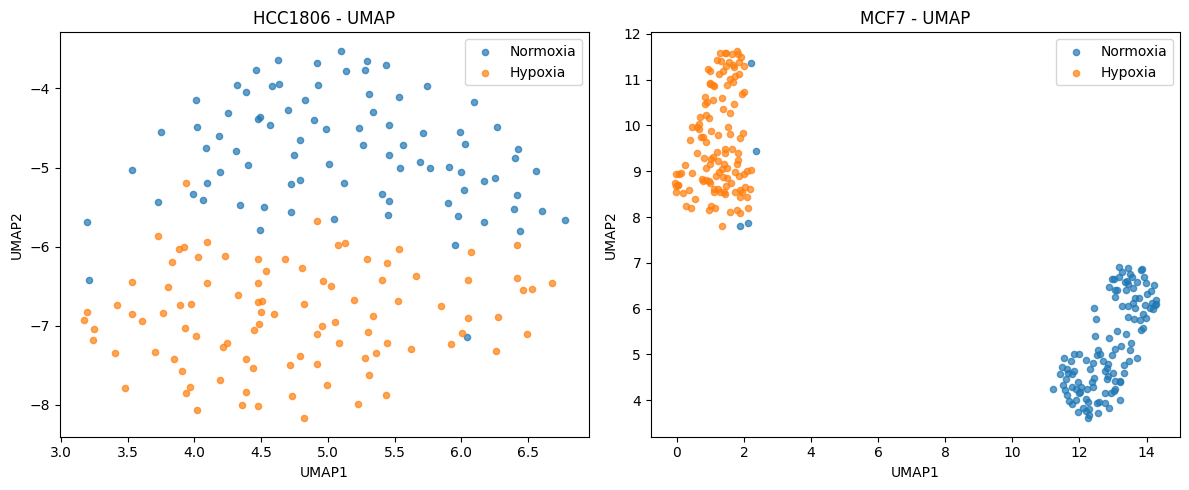

In [36]:
# FIX: this section now actually plots UMAP 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, labels, title in zip(
    axes,
    [hcc_umap, mcf_umap],
    [hcc["condition"], mcf["condition"]],
    ["HCC1806 - UMAP", "MCF7 - UMAP"],
):
    for cond, color in zip(["Normoxia", "Hypoxia"], [PALETTE[0], PALETTE[1]]):
        m = labels.values == cond
        ax.scatter(data[m, 0], data[m, 1], label=cond,
                   color=color, s=20, alpha=0.7)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

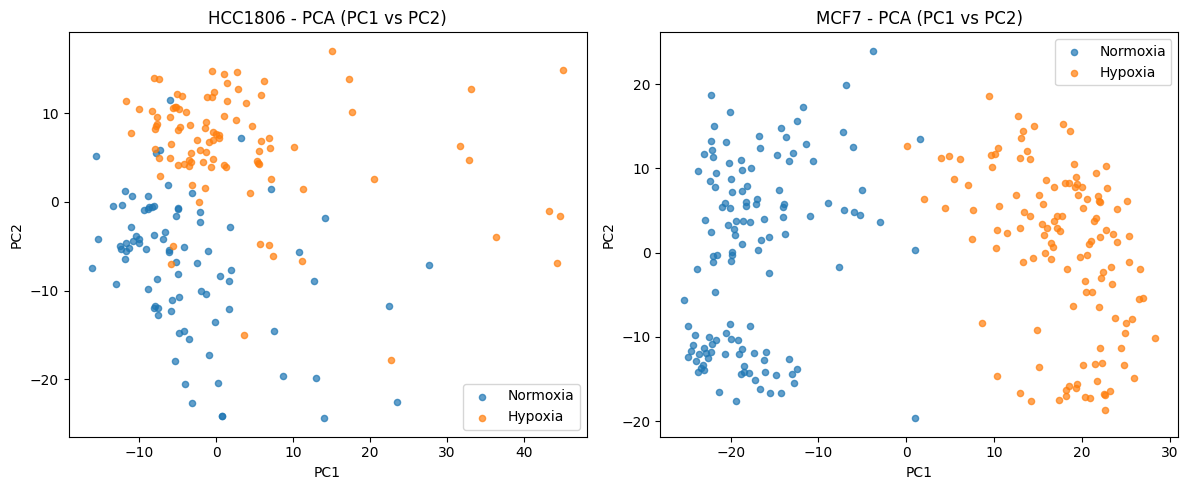

In [37]:
# PCA scatter (PC1 vs PC2) coloured by condition, for reference
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, labels, title in zip(
    axes,
    [hcc_pca, mcf_pca],
    [hcc["condition"], mcf["condition"]],
    ["HCC1806 - PCA (PC1 vs PC2)", "MCF7 - PCA (PC1 vs PC2)"],
):
    for cond, color in zip(["Normoxia", "Hypoxia"], [PALETTE[0], PALETTE[1]]):
        m = labels.values == cond
        ax.scatter(data[m, 0], data[m, 1], label=cond,
                   color=color, s=20, alpha=0.7)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Cluster Analysis

**Methodological note.** As a general principle, clustering is more
reliable on a distance-preserving space (PCA) than on non-linear 2-D
embeddings (t-SNE/UMAP), whose pairwise distances are distorted. We
therefore run every algorithm on **all three spaces** and compare them
externally in §4 rather than assuming one is best. As the results show,
this assumption does **not** hold uniformly: for MCF7 the PCA space
works best, but for HCC1806 PCA fails at every dimensionality (see the
diagnostic in §2.1) and only the non-linear UMAP embedding recovers the
biological structure. The space-vs-method comparison is thus an
empirical result of this work, not a fixed assumption.

### 3.1 Optimal number of clusters (elbow + silhouette)

#### 3.1.1 On PCA space

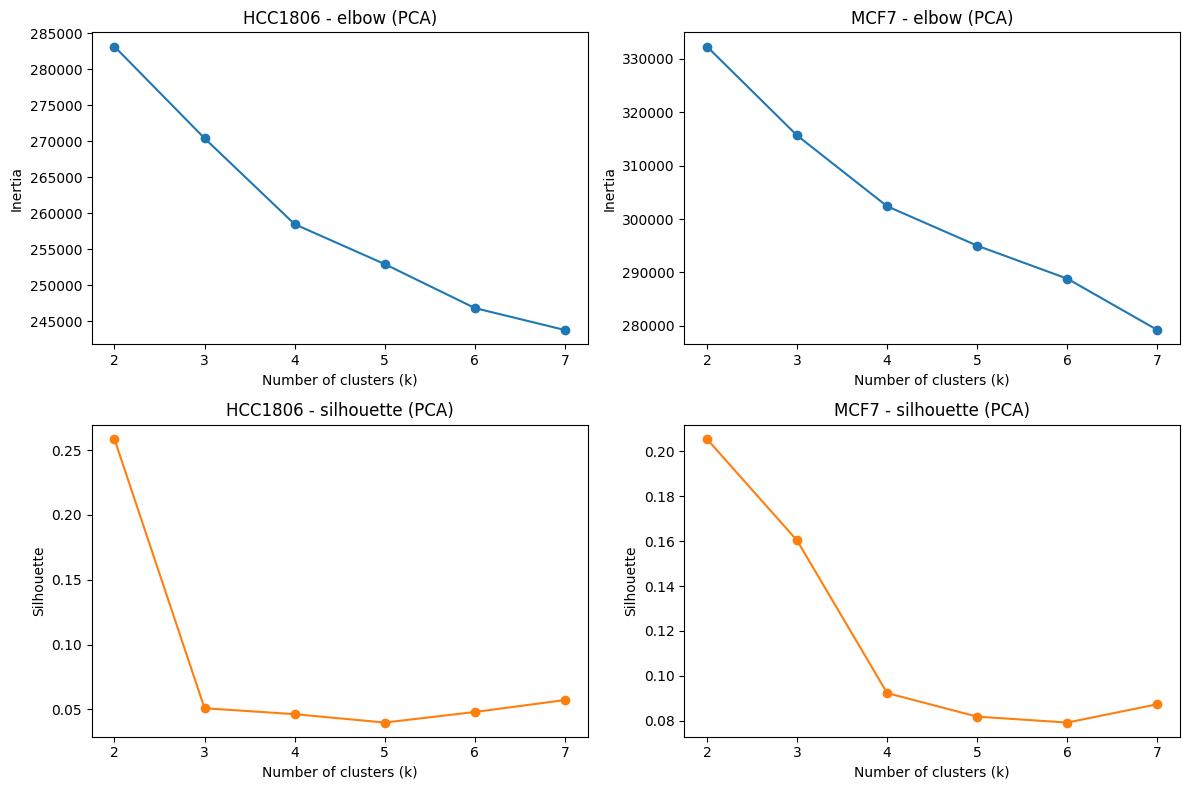

In [38]:
k_range = range(2, 8)

def k_scan(X):
    inertia, sil = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        lab = km.fit_predict(X)
        inertia.append(km.inertia_)
        sil.append(silhouette_score(X, lab))
    return inertia, sil

inertia_hcc, silhouette_hcc = k_scan(hcc_pca)
inertia_mcf, silhouette_mcf = k_scan(mcf_pca)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(k_range, inertia_hcc, "o-")
axes[0, 0].set_title("HCC1806 - elbow (PCA)")
axes[0, 1].plot(k_range, inertia_mcf, "o-")
axes[0, 1].set_title("MCF7 - elbow (PCA)")
axes[1, 0].plot(k_range, silhouette_hcc, "o-", color=PALETTE[1])
axes[1, 0].set_title("HCC1806 - silhouette (PCA)")
axes[1, 1].plot(k_range, silhouette_mcf, "o-", color=PALETTE[1])
axes[1, 1].set_title("MCF7 - silhouette (PCA)")
for ax in axes.flat:
    ax.set_xlabel("Number of clusters (k)")
axes[0, 0].set_ylabel("Inertia"); axes[0, 1].set_ylabel("Inertia")
axes[1, 0].set_ylabel("Silhouette"); axes[1, 1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

On the PCA space we keep **k = 2** for both HCC1806 and MCF7, consistent with the two experimental conditions.

#### 3.1.2 On t-SNE space (comparison only)

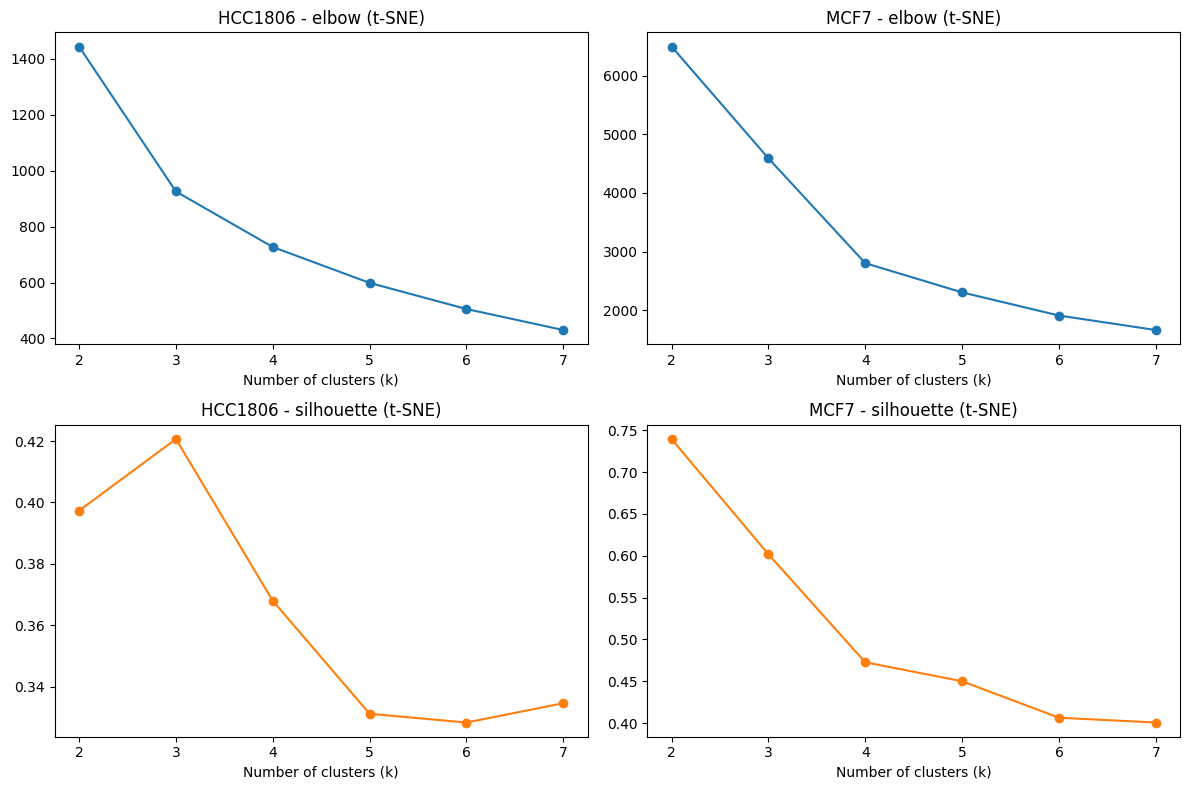

In [39]:
inertia_hcc_t, sil_hcc_t = k_scan(hcc_tsne)
inertia_mcf_t, sil_mcf_t = k_scan(mcf_tsne)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(k_range, inertia_hcc_t, "o-")
axes[0, 0].set_title("HCC1806 - elbow (t-SNE)")
axes[0, 1].plot(k_range, inertia_mcf_t, "o-")
axes[0, 1].set_title("MCF7 - elbow (t-SNE)")
axes[1, 0].plot(k_range, sil_hcc_t, "o-", color=PALETTE[1])
axes[1, 0].set_title("HCC1806 - silhouette (t-SNE)")
axes[1, 1].plot(k_range, sil_mcf_t, "o-", color=PALETTE[1])
axes[1, 1].set_title("MCF7 - silhouette (t-SNE)")
for ax in axes.flat:
    ax.set_xlabel("Number of clusters (k)")
plt.tight_layout()
plt.show()

On the t-SNE embedding the silhouette suggests **k = 3** for HCC1806 and **k = 2** for MCF7 (comparison only).

#### 3.1.3 On UMAP space (comparison only)

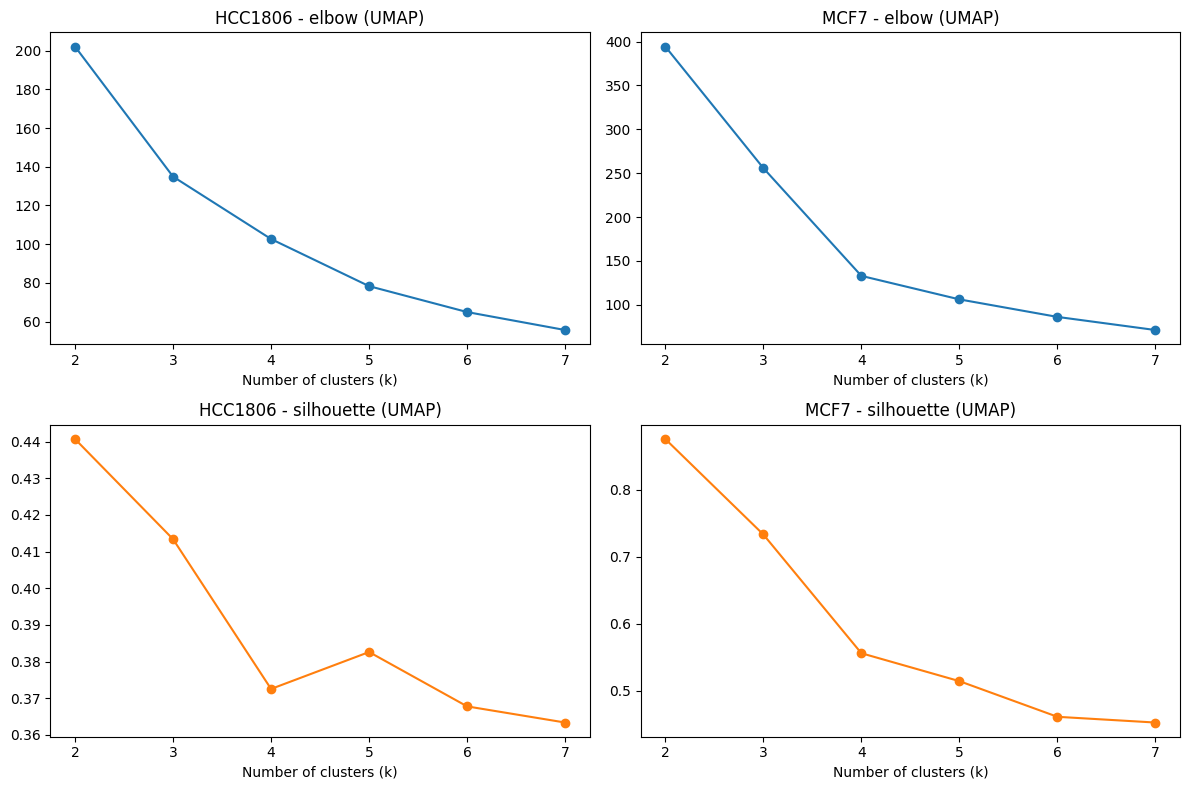

In [40]:
inertia_hcc_u, sil_hcc_u = k_scan(hcc_umap)
inertia_mcf_u, sil_mcf_u = k_scan(mcf_umap)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(k_range, inertia_hcc_u, "o-")
axes[0, 0].set_title("HCC1806 - elbow (UMAP)")
axes[0, 1].plot(k_range, inertia_mcf_u, "o-")
axes[0, 1].set_title("MCF7 - elbow (UMAP)")
axes[1, 0].plot(k_range, sil_hcc_u, "o-", color=PALETTE[1])
axes[1, 0].set_title("HCC1806 - silhouette (UMAP)")
axes[1, 1].plot(k_range, sil_mcf_u, "o-", color=PALETTE[1])
axes[1, 1].set_title("MCF7 - silhouette (UMAP)")
for ax in axes.flat:
    ax.set_xlabel("Number of clusters (k)")
plt.tight_layout()
plt.show()

On the UMAP embedding we keep **k = 2** for both (comparison only).

### 3.2 K-means clustering

#### 3.2.1 K-means on PCA

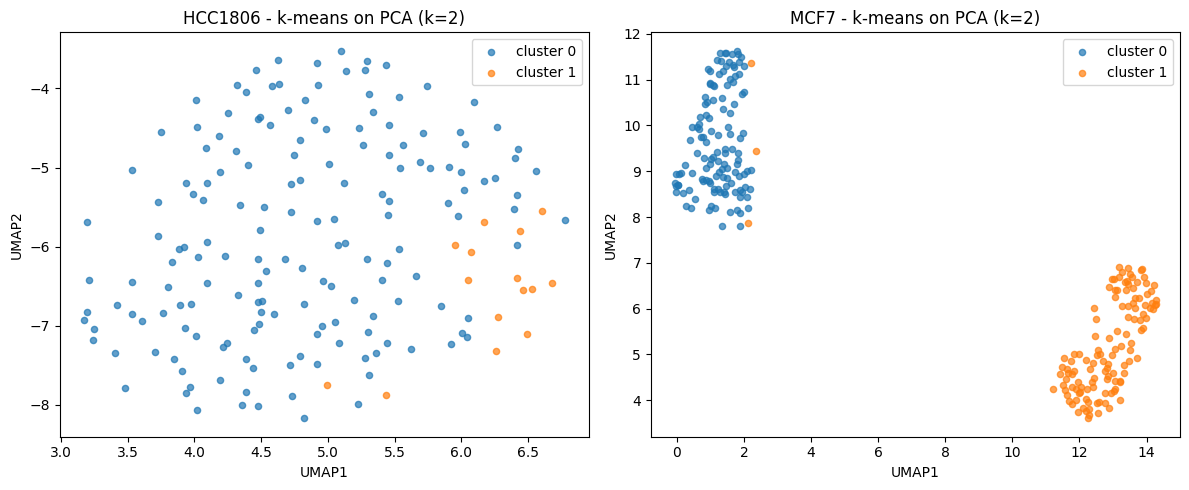

In [41]:
km_hcc = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
hcc_kmeans_labels = km_hcc.fit_predict(hcc_pca)

km_mcf = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
mcf_kmeans_labels = km_mcf.fit_predict(mcf_pca)

# Visualised on UMAP (embedding used only to display the PCA-space clusters)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, emb, lab, title in zip(
    axes,
    [hcc_umap, mcf_umap],
    [hcc_kmeans_labels, mcf_kmeans_labels],
    ["HCC1806 - k-means on PCA (k=2)", "MCF7 - k-means on PCA (k=2)"],
):
    for cl in np.unique(lab):
        m = lab == cl
        ax.scatter(emb[m, 0], emb[m, 1], color=PALETTE[cl],
                   s=20, alpha=0.7, label=f"cluster {cl}")
    ax.legend()
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2"); ax.set_title(title)
plt.tight_layout()
plt.show()

In [42]:
hcc_km_df = pd.DataFrame({
    "cluster": hcc_kmeans_labels,
    "condition": hcc["condition"].values,
})
print("HCC1806 k-means/PCA - composition (counts):")
print(pd.crosstab(hcc_km_df["cluster"], hcc_km_df["condition"]))
print("\nHCC1806 k-means/PCA - composition (row %):")
print(pd.crosstab(hcc_km_df["cluster"], hcc_km_df["condition"],
                  normalize="index").round(2))
print()
mcf_km_df = pd.DataFrame({
    "cluster": mcf_kmeans_labels,
    "condition": mcf["condition"].values,
})
print("MCF7 k-means/PCA - composition (counts):")
print(pd.crosstab(mcf_km_df["cluster"], mcf_km_df["condition"]))
print("\nMCF7 k-means/PCA - composition (row %):")
print(pd.crosstab(mcf_km_df["cluster"], mcf_km_df["condition"],
                  normalize="index").round(2))

HCC1806 k-means/PCA - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0               86        81
1               11         4

HCC1806 k-means/PCA - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.51      0.49
1             0.73      0.27

MCF7 k-means/PCA - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0              124         1
1                0       125

MCF7 k-means/PCA - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.99      0.01
1             0.00      1.00


#### 3.2.2 K-means on t-SNE (comparison only)

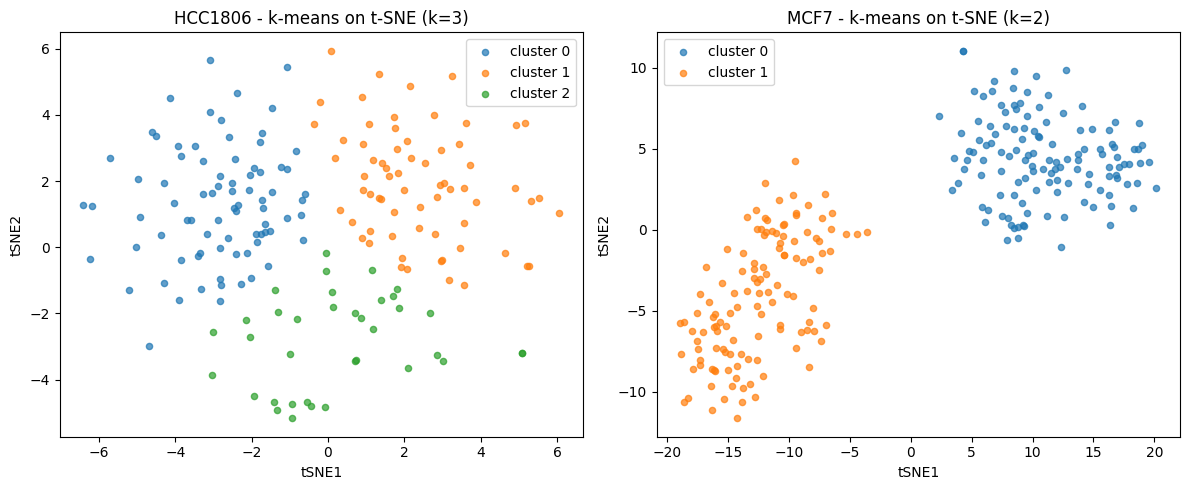

In [43]:
# k chosen from 3.1.2: HCC=3, MCF=2
km_tsne_hcc = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
hcc_kmeans_tsne_labels = km_tsne_hcc.fit_predict(hcc_tsne)

km_tsne_mcf = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
mcf_kmeans_tsne_labels = km_tsne_mcf.fit_predict(mcf_tsne)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, lab, title, ncl in zip(
    axes,
    [hcc_tsne, mcf_tsne],
    [hcc_kmeans_tsne_labels, mcf_kmeans_tsne_labels],
    ["HCC1806 - k-means on t-SNE (k=3)", "MCF7 - k-means on t-SNE (k=2)"],
    [3, 2],
):
    for c in range(ncl):
        m = lab == c
        ax.scatter(data[m, 0], data[m, 1], label=f"cluster {c}",
                   color=PALETTE[c], s=20, alpha=0.7)
    ax.set_xlabel("tSNE1"); ax.set_ylabel("tSNE2")
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.show()

In [44]:
hcc_km_tsne_df = pd.DataFrame({
    "cluster": hcc_kmeans_tsne_labels,
    "condition": hcc["condition"].values,
})
print("HCC1806 k-means/t-SNE - composition (counts):")
print(pd.crosstab(hcc_km_tsne_df["cluster"], hcc_km_tsne_df["condition"]))
print("\nHCC1806 k-means/t-SNE - composition (row %):")
print(pd.crosstab(hcc_km_tsne_df["cluster"], hcc_km_tsne_df["condition"],
                  normalize="index").round(2))
print()
mcf_km_tsne_df = pd.DataFrame({
    "cluster": mcf_kmeans_tsne_labels,
    "condition": mcf["condition"].values,
})
print("MCF7 k-means/t-SNE - composition (counts):")
print(pd.crosstab(mcf_km_tsne_df["cluster"], mcf_km_tsne_df["condition"]))
print("\nMCF7 k-means/t-SNE - composition (row %):")
print(pd.crosstab(mcf_km_tsne_df["cluster"], mcf_km_tsne_df["condition"],
                  normalize="index").round(2))

HCC1806 k-means/t-SNE - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0               75         4
1                5        62
2               17        19

HCC1806 k-means/t-SNE - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.95      0.05
1             0.07      0.93
2             0.47      0.53

MCF7 k-means/t-SNE - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0              124         3
1                0       123

MCF7 k-means/t-SNE - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.98      0.02
1             0.00      1.00


#### 3.2.3 K-means on UMAP (comparison only)

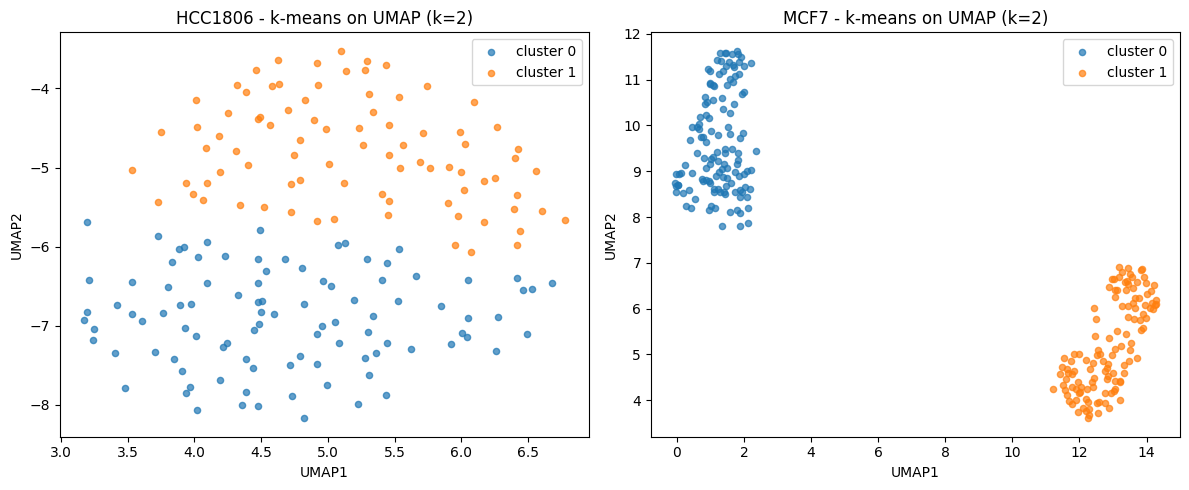

In [45]:
km_umap_hcc = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
hcc_kmeans_umap_labels = km_umap_hcc.fit_predict(hcc_umap)

km_umap_mcf = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
mcf_kmeans_umap_labels = km_umap_mcf.fit_predict(mcf_umap)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, lab, title in zip(
    axes,
    [hcc_umap, mcf_umap],
    [hcc_kmeans_umap_labels, mcf_kmeans_umap_labels],
    ["HCC1806 - k-means on UMAP (k=2)", "MCF7 - k-means on UMAP (k=2)"],
):
    for c, color in zip([0, 1], [PALETTE[0], PALETTE[1]]):
        m = lab == c
        ax.scatter(data[m, 0], data[m, 1], label=f"cluster {c}",
                   color=color, s=20, alpha=0.7)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.show()

In [46]:
hcc_km_umap_df = pd.DataFrame({
    "cluster": hcc_kmeans_umap_labels,
    "condition": hcc["condition"].values,
})
print("HCC1806 k-means/UMAP - composition (counts):")
print(pd.crosstab(hcc_km_umap_df["cluster"], hcc_km_umap_df["condition"]))
print("\nHCC1806 k-means/UMAP - composition (row %):")
print(pd.crosstab(hcc_km_umap_df["cluster"], hcc_km_umap_df["condition"],
                  normalize="index").round(2))
print()
mcf_km_umap_df = pd.DataFrame({
    "cluster": mcf_kmeans_umap_labels,
    "condition": mcf["condition"].values,
})
print("MCF7 k-means/UMAP - composition (counts):")
print(pd.crosstab(mcf_km_umap_df["cluster"], mcf_km_umap_df["condition"]))
print("\nMCF7 k-means/UMAP - composition (row %):")
print(pd.crosstab(mcf_km_umap_df["cluster"], mcf_km_umap_df["condition"],
                  normalize="index").round(2))

HCC1806 k-means/UMAP - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0               93         4
1                4        81

HCC1806 k-means/UMAP - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.96      0.04
1             0.05      0.95

MCF7 k-means/UMAP - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0              124         4
1                0       122

MCF7 k-means/UMAP - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.97      0.03
1             0.00      1.00


### 3.3 Hierarchical agglomerative clustering

#### 3.3.1 Hierarchical on PCA

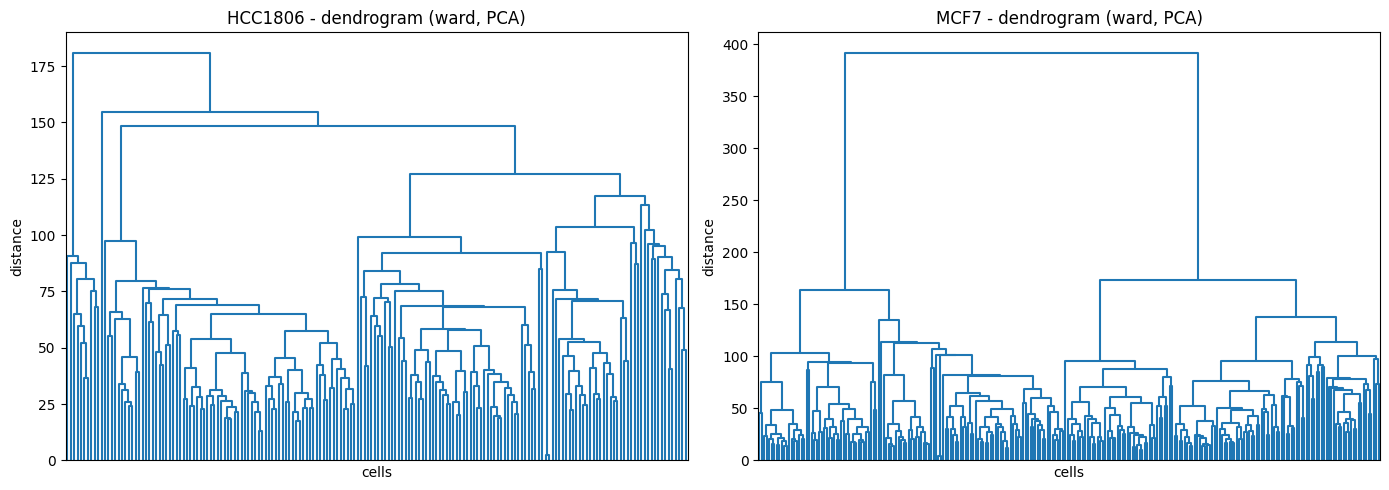

In [47]:
linkage_hcc = linkage(hcc_pca, method="ward")
linkage_mcf = linkage(mcf_pca, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dendrogram(linkage_hcc, ax=axes[0], no_labels=True, color_threshold=0)
axes[0].set_title("HCC1806 - dendrogram (ward, PCA)")
axes[0].set_xlabel("cells"); axes[0].set_ylabel("distance")
dendrogram(linkage_mcf, ax=axes[1], no_labels=True, color_threshold=0)
axes[1].set_title("MCF7 - dendrogram (ward, PCA)")
axes[1].set_xlabel("cells"); axes[1].set_ylabel("distance")
plt.tight_layout()
plt.show()

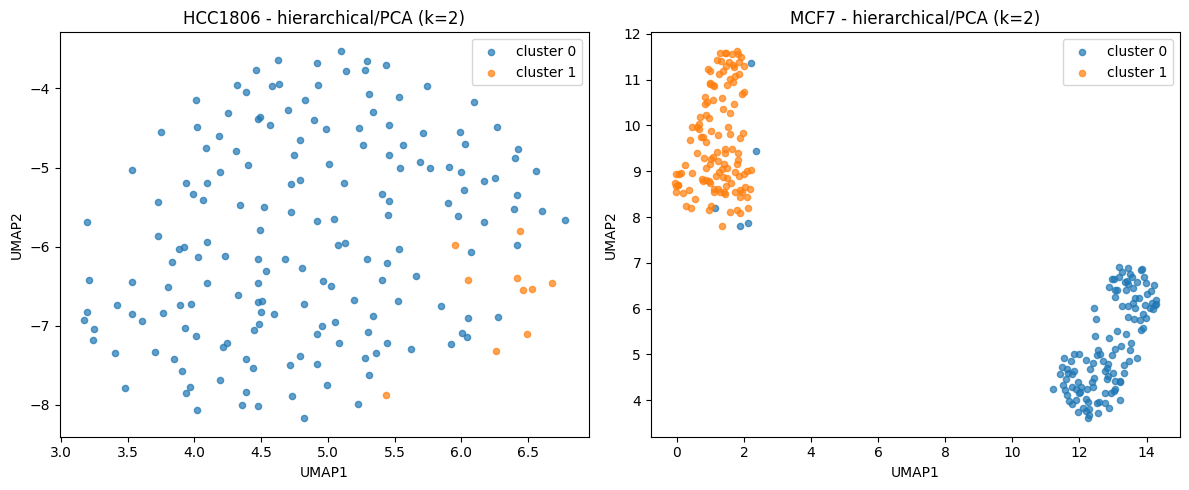

In [48]:
agg_hcc = AgglomerativeClustering(n_clusters=2)
hcc_agg_labels = agg_hcc.fit_predict(hcc_pca)

agg_mcf = AgglomerativeClustering(n_clusters=2)
mcf_agg_labels = agg_mcf.fit_predict(mcf_pca)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, emb, lab, title in zip(
    axes,
    [hcc_umap, mcf_umap],
    [hcc_agg_labels, mcf_agg_labels],
    ["HCC1806 - hierarchical/PCA (k=2)", "MCF7 - hierarchical/PCA (k=2)"],
):
    for c, color in zip([0, 1], [PALETTE[0], PALETTE[1]]):
        m = lab == c
        ax.scatter(emb[m, 0], emb[m, 1], label=f"cluster {c}",
                   color=color, s=20, alpha=0.7)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.show()

In [49]:
hcc_agg_pca_df = pd.DataFrame({
    "cluster": hcc_agg_labels,
    "condition": hcc["condition"].values,
})
print("HCC1806 hier/PCA - composition (counts):")
print(pd.crosstab(hcc_agg_pca_df["cluster"], hcc_agg_pca_df["condition"]))
print("\nHCC1806 hier/PCA - composition (row %):")
print(pd.crosstab(hcc_agg_pca_df["cluster"], hcc_agg_pca_df["condition"],
                  normalize="index").round(2))
print()
mcf_agg_pca_df = pd.DataFrame({
    "cluster": mcf_agg_labels,
    "condition": mcf["condition"].values,
})
print("MCF7 hier/PCA - composition (counts):")
print(pd.crosstab(mcf_agg_pca_df["cluster"], mcf_agg_pca_df["condition"]))
print("\nMCF7 hier/PCA - composition (row %):")
print(pd.crosstab(mcf_agg_pca_df["cluster"], mcf_agg_pca_df["condition"],
                  normalize="index").round(2))

HCC1806 hier/PCA - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0               89        83
1                8         2

HCC1806 hier/PCA - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.52      0.48
1             0.80      0.20

MCF7 hier/PCA - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0                1       126
1              123         0

MCF7 hier/PCA - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.01      0.99
1             1.00      0.00


#### 3.3.2 Hierarchical on t-SNE (comparison only)

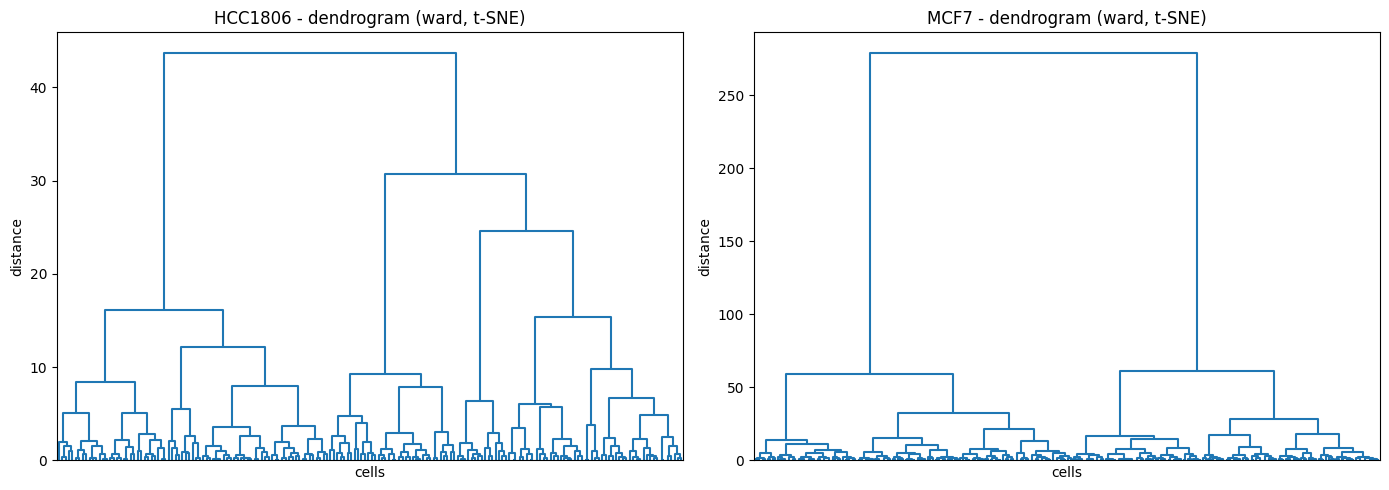

In [50]:
linkage_hcc_t = linkage(hcc_tsne, method="ward")
linkage_mcf_t = linkage(mcf_tsne, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dendrogram(linkage_hcc_t, ax=axes[0], no_labels=True, color_threshold=0)
axes[0].set_title("HCC1806 - dendrogram (ward, t-SNE)")
dendrogram(linkage_mcf_t, ax=axes[1], no_labels=True, color_threshold=0)
axes[1].set_title("MCF7 - dendrogram (ward, t-SNE)")
for ax in axes:
    ax.set_xlabel("cells"); ax.set_ylabel("distance")
plt.tight_layout()
plt.show()

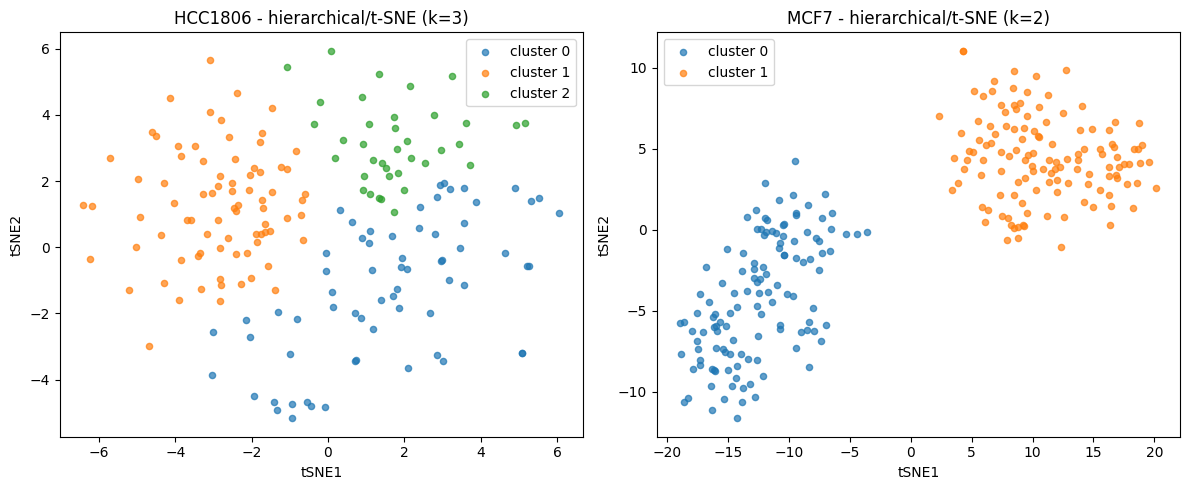

In [51]:
# k consistent with 3.1.2: HCC=3, MCF=2
agg_t_hcc = AgglomerativeClustering(n_clusters=3)
hcc_agg_tsne_labels = agg_t_hcc.fit_predict(hcc_tsne)

agg_t_mcf = AgglomerativeClustering(n_clusters=2)
mcf_agg_tsne_labels = agg_t_mcf.fit_predict(mcf_tsne)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, lab, title, ncl in zip(
    axes,
    [hcc_tsne, mcf_tsne],
    [hcc_agg_tsne_labels, mcf_agg_tsne_labels],
    ["HCC1806 - hierarchical/t-SNE (k=3)",
     "MCF7 - hierarchical/t-SNE (k=2)"],
    [3, 2],
):
    for c in range(ncl):
        m = lab == c
        ax.scatter(data[m, 0], data[m, 1], label=f"cluster {c}",
                   color=PALETTE[c], s=20, alpha=0.7)
    ax.set_xlabel("tSNE1"); ax.set_ylabel("tSNE2")
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.show()

In [52]:
hcc_agg_tsne_df = pd.DataFrame({
    "cluster": hcc_agg_tsne_labels,
    "condition": hcc["condition"].values,
})
print("HCC1806 hier/t-SNE - composition (counts):")
print(pd.crosstab(hcc_agg_tsne_df["cluster"], hcc_agg_tsne_df["condition"]))
print("\nHCC1806 hier/t-SNE - composition (row %):")
print(pd.crosstab(hcc_agg_tsne_df["cluster"], hcc_agg_tsne_df["condition"],
                  normalize="index").round(2))
print()
mcf_agg_tsne_df = pd.DataFrame({
    "cluster": mcf_agg_tsne_labels,
    "condition": mcf["condition"].values,
})
print("MCF7 hier/t-SNE - composition (counts):")
print(pd.crosstab(mcf_agg_tsne_df["cluster"], mcf_agg_tsne_df["condition"]))
print("\nMCF7 hier/t-SNE - composition (row %):")
print(pd.crosstab(mcf_agg_tsne_df["cluster"], mcf_agg_tsne_df["condition"],
                  normalize="index").round(2))

HCC1806 hier/t-SNE - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0               21        45
1               76         3
2                0        37

HCC1806 hier/t-SNE - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.32      0.68
1             0.96      0.04
2             0.00      1.00

MCF7 hier/t-SNE - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0                0       123
1              124         3

MCF7 hier/t-SNE - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.00      1.00
1             0.98      0.02


#### 3.3.3 Hierarchical on UMAP (comparison only)

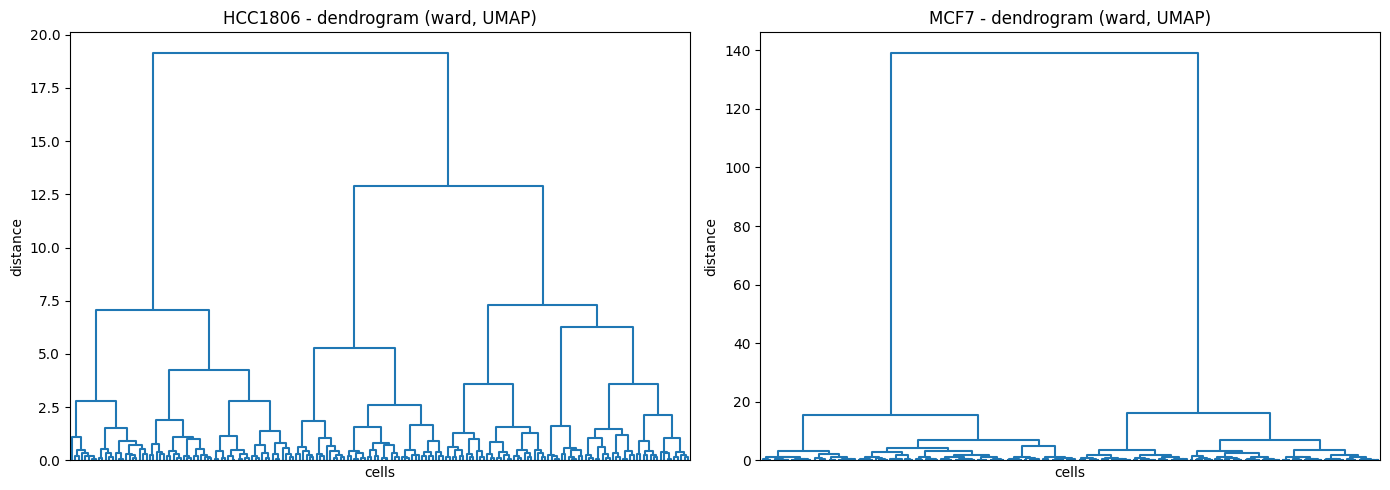

In [53]:
linkage_hcc_u = linkage(hcc_umap, method="ward")
linkage_mcf_u = linkage(mcf_umap, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dendrogram(linkage_hcc_u, ax=axes[0], no_labels=True, color_threshold=0)
axes[0].set_title("HCC1806 - dendrogram (ward, UMAP)")
dendrogram(linkage_mcf_u, ax=axes[1], no_labels=True, color_threshold=0)
axes[1].set_title("MCF7 - dendrogram (ward, UMAP)")
for ax in axes:
    ax.set_xlabel("cells"); ax.set_ylabel("distance")
plt.tight_layout()
plt.show()

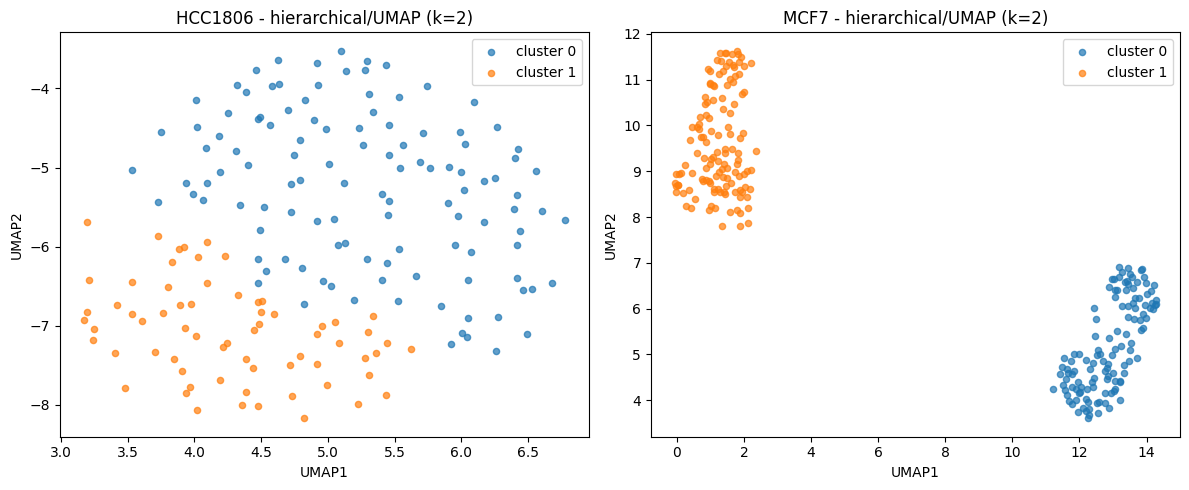

In [54]:
agg_u_hcc = AgglomerativeClustering(n_clusters=2)
hcc_agg_umap_labels = agg_u_hcc.fit_predict(hcc_umap)

agg_u_mcf = AgglomerativeClustering(n_clusters=2)
mcf_agg_umap_labels = agg_u_mcf.fit_predict(mcf_umap)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, lab, title in zip(
    axes,
    [hcc_umap, mcf_umap],
    [hcc_agg_umap_labels, mcf_agg_umap_labels],
    ["HCC1806 - hierarchical/UMAP (k=2)",
     "MCF7 - hierarchical/UMAP (k=2)"],
):
    for c, color in zip([0, 1], [PALETTE[0], PALETTE[1]]):
        m = lab == c
        ax.scatter(data[m, 0], data[m, 1], label=f"cluster {c}",
                   color=color, s=20, alpha=0.7)
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ax.set_title(title); ax.legend()
plt.tight_layout()
plt.show()

In [55]:
hcc_agg_umap_df = pd.DataFrame({
    "cluster": hcc_agg_umap_labels,
    "condition": hcc["condition"].values,
})
print("HCC1806 hier/UMAP - composition (counts):")
print(pd.crosstab(hcc_agg_umap_df["cluster"], hcc_agg_umap_df["condition"]))
print("\nHCC1806 hier/UMAP - composition (row %):")
print(pd.crosstab(hcc_agg_umap_df["cluster"], hcc_agg_umap_df["condition"],
                  normalize="index").round(2))
print()
mcf_agg_umap_df = pd.DataFrame({
    "cluster": mcf_agg_umap_labels,
    "condition": mcf["condition"].values,
})
print("MCF7 hier/UMAP - composition (counts):")
print(pd.crosstab(mcf_agg_umap_df["cluster"], mcf_agg_umap_df["condition"]))
print("\nMCF7 hier/UMAP - composition (row %):")
print(pd.crosstab(mcf_agg_umap_df["cluster"], mcf_agg_umap_df["condition"],
                  normalize="index").round(2))

HCC1806 hier/UMAP - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0               33        83
1               64         2

HCC1806 hier/UMAP - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.28      0.72
1             0.97      0.03

MCF7 hier/UMAP - composition (counts):
condition  Hypoxia  Normoxia
cluster                     
0                0       122
1              124         4

MCF7 hier/UMAP - composition (row %):
condition  Hypoxia  Normoxia
cluster                     
0             0.00      1.00
1             0.97      0.03


## 4. Cluster Evaluation

Each clustering is compared to the true experimental condition
(Hypoxia/Normoxia) using **NMI** and **ARI**. Both are appropriate here
because the classes are roughly balanced. The condition labels were
never used during fitting, so this is a valid external evaluation.

### 4.1 Cluster composition by condition

In [56]:
conditions = {
    "HCC1806": hcc["condition"].values,
    "MCF7":    mcf["condition"].values,
}

datasets = {
    "HCC1806": {
        "K-means on PCA":        hcc_kmeans_labels,
        "K-means on t-SNE":      hcc_kmeans_tsne_labels,
        "K-means on UMAP":       hcc_kmeans_umap_labels,
        "Hierarchical on PCA":   hcc_agg_labels,
        "Hierarchical on t-SNE": hcc_agg_tsne_labels,
        "Hierarchical on UMAP":  hcc_agg_umap_labels,
    },
    "MCF7": {
        "K-means on PCA":        mcf_kmeans_labels,
        "K-means on t-SNE":      mcf_kmeans_tsne_labels,
        "K-means on UMAP":       mcf_kmeans_umap_labels,
        "Hierarchical on PCA":   mcf_agg_labels,
        "Hierarchical on t-SNE": mcf_agg_tsne_labels,
        "Hierarchical on UMAP":  mcf_agg_umap_labels,
    },
}

rows = []
for ds, methods in datasets.items():
    truth = conditions[ds]
    for method, lab in methods.items():
        rows.append({
            "dataset": ds,
            "method":  method,
            "space":   method.split(" on ")[-1],
            "NMI":     round(normalized_mutual_info_score(truth, lab), 3),
            "ARI":     round(adjusted_rand_score(truth, lab), 3),
        })

summary = pd.DataFrame(rows)
best_idx = summary.groupby("dataset")["NMI"].idxmax()

styled = (
    summary.style
    .format({"NMI": "{:.3f}", "ARI": "{:.3f}"})
    .apply(lambda r: ["background-color: #ffe9a8"
                      if r.name in best_idx.values else "" for _ in r],
           axis=1)
)
display(styled)

,dataset,method,space,NMI,ARI
0,HCC1806,K-means on PCA,PCA,0.016,-0.005
1,HCC1806,K-means on t-SNE,t-SNE,0.424,0.493
2,HCC1806,K-means on UMAP,UMAP,0.739,0.831
3,HCC1806,Hierarchical on PCA,PCA,0.020,-0.005
4,HCC1806,Hierarchical on t-SNE,t-SNE,0.452,0.432
5,HCC1806,Hierarchical on UMAP,UMAP,0.388,0.375
6,MCF7,K-means on PCA,PCA,0.966,0.984
7,MCF7,K-means on t-SNE,t-SNE,0.918,0.952
8,MCF7,K-means on UMAP,UMAP,0.897,0.937
9,MCF7,Hierarchical on PCA,PCA,0.966,0.984


### 4.2 Discussion

The two datasets show **opposite regimes**, which is the main empirical
result of this analysis:

- **MCF7** has a strong, essentially linear condition structure:
  K-means on the PCA space already separates Hypoxia/Normoxia almost
  perfectly (NMI ~ 0.97, ARI ~ 0.98), and t-SNE/UMAP perform comparably.
- **HCC1806** behaves the opposite way: PCA-space clustering is no
  better than random (NMI ~ 0.02, ARI ~ 0 - and the §2.1 diagnostic
  shows this holds at *every* number of PCs, from 2 to 60, so it is not
  a dimensionality-tuning artefact). Only the non-linear **UMAP**
  embedding recovers the condition structure (K-means on UMAP:
  NMI ~ 0.74, ARI ~ 0.83).

Interpretation: in MCF7 the Hypoxia/Normoxia signal lies along
directions of high linear variance, so PCA captures it directly. In
HCC1806 the signal is not linearly separable - PCA's leading components
capture other sources of variation (cellular heterogeneity, technical
noise) and the two conditions stay mixed at any linear dimensionality.
A non-linear embedding is required to expose it. The "PCA is always
preferable for clustering" rule is therefore dataset-dependent, and
comparing multiple representation spaces was necessary, not optional.

## 5. Biological Interpretation

Marker genes are identified for the **best clustering of each dataset**
as established in §4: K-means on **UMAP** for HCC1806 (the only space
that recovers its structure) and K-means on **PCA** for MCF7. Using the
PCA clustering for HCC1806 would mean computing markers on essentially
random groups (ARI ~ 0), which would be meaningless - the embedding
choice per dataset is dictated by the §4 evaluation and the §2.1
diagnostic, not by preference.

For each cluster, genes over-expressed versus the rest are found with a
one-sided Mann-Whitney U test and **Benjamini-Hochberg FDR correction**;
the `mean_diff` column is the difference of mean log-expression between
groups (not a true log2 fold change, hence the explicit name).

In [57]:
def get_top_marker_genes(X_df, labels, n_genes=15, fdr=0.05):
    """Per cluster: Mann-Whitney U (one vs rest), BH-FDR corrected.
    Returns the top up-regulated, significant genes per cluster."""
    from statsmodels.stats.multitest import multipletests

    marker_genes = []
    for c in sorted(np.unique(labels)):
        m_c = labels == c
        m_o = ~m_c

        recs = []
        for gene in X_df.columns:
            a = X_df.loc[m_c, gene]
            b = X_df.loc[m_o, gene]
            _, p = stats.mannwhitneyu(a, b, alternative="greater")
            recs.append((gene, a.mean() - b.mean(), p))

        d = pd.DataFrame(recs, columns=["gene", "mean_diff", "pval"])
        d["padj"] = multipletests(d["pval"], method="fdr_bh")[1]
        d = d[d["padj"] < fdr].sort_values("mean_diff", ascending=False)
        marker_genes.extend(d.head(n_genes)["gene"].tolist())

    return list(dict.fromkeys(marker_genes))

### 5.1 Heatmap of marker genes by cluster

We use the **best clustering per dataset** as identified in §4 (read the
method from the evaluation table — typically the PCA-space clustering).
Adjust the label variables below if a different method wins on your
run.

In [58]:
# Best clustering per dataset, from section 4 + the section 2.1
# PC-sensitivity diagnostic:
#   - HCC1806: K-means on UMAP   (PCA fails at every dimensionality)
#   - MCF7   : K-means on PCA    (strong linear structure)
hcc_best_labels = hcc_kmeans_umap_labels   # HCC: UMAP is the only space that works
mcf_best_labels = mcf_kmeans_labels        # MCF: PCA k-means (best overall)

hcc_X = hcc_gc.copy()
mcf_X = mcf_gc.copy()
hcc_X["cluster"] = hcc_best_labels
mcf_X["cluster"] = mcf_best_labels

hcc_X = hcc_X.sort_values("cluster")
mcf_X = mcf_X.sort_values("cluster")

de_hcc = get_top_marker_genes(hcc_X.drop(columns="cluster"),
                              hcc_X["cluster"].values, n_genes=15)
de_mcf = get_top_marker_genes(mcf_X.drop(columns="cluster"),
                              mcf_X["cluster"].values, n_genes=15)

print(f"HCC1806: {len(de_hcc)} marker genes")
print(f"MCF7:   {len(de_mcf)} marker genes")

HCC1806: 30 marker genes
MCF7:   30 marker genes


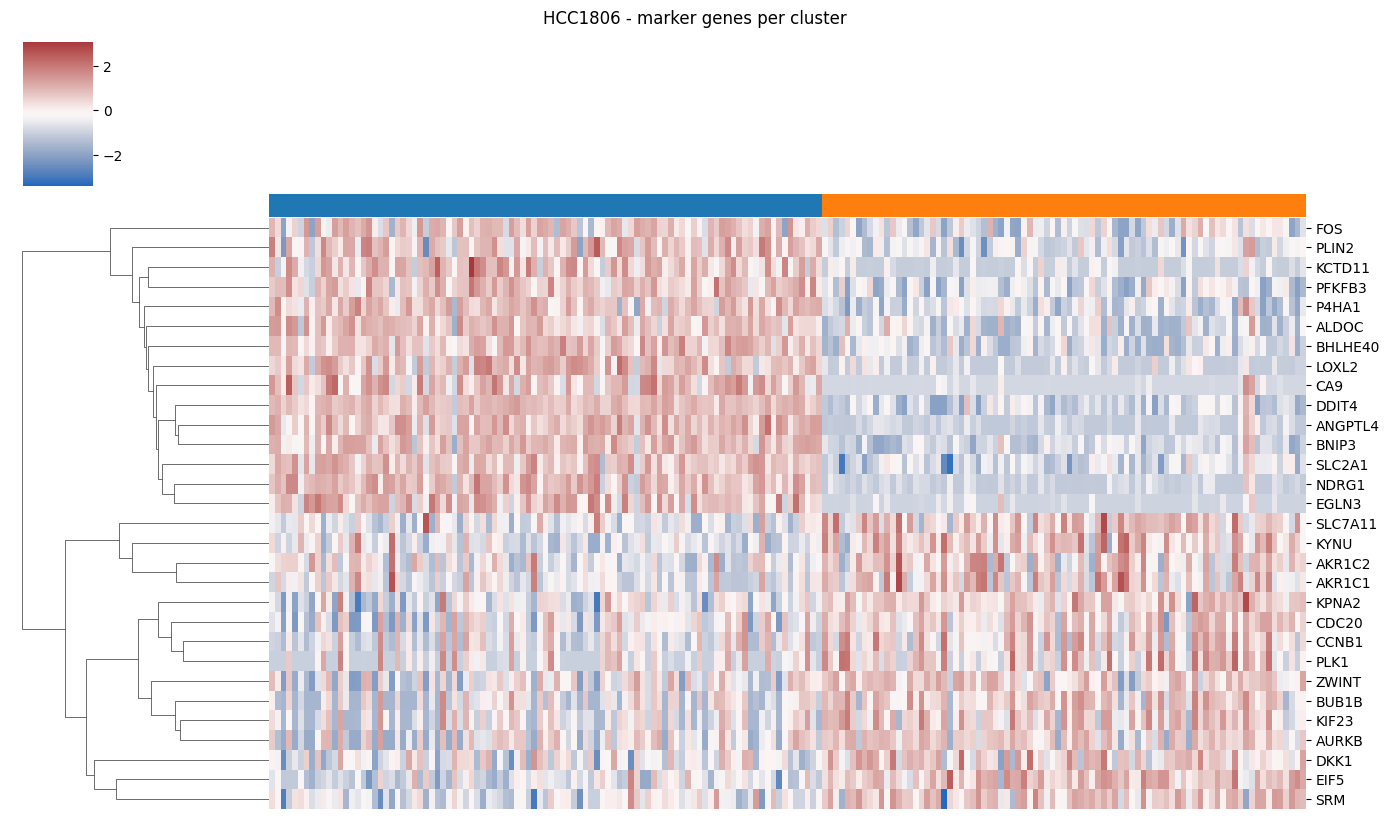

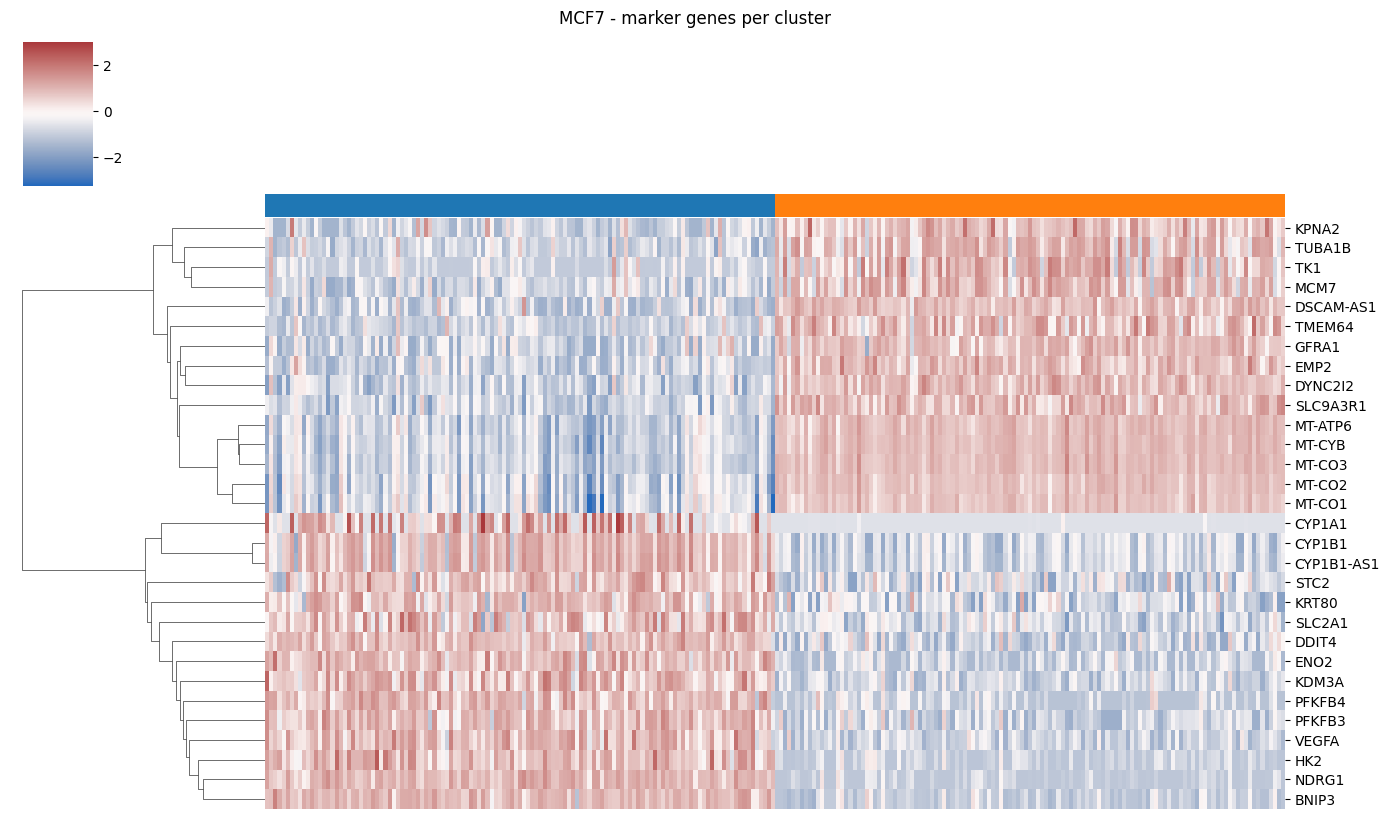

In [59]:
def cluster_heatmap(X_sorted, genes, title):
    palette = {i: PALETTE[i] for i in range(4)}
    col_colors = X_sorted["cluster"].map(palette)
    sns.clustermap(
        X_sorted[genes].T,
        col_colors=col_colors.values,
        col_cluster=False, row_cluster=True,
        cmap="vlag", z_score=0,
        figsize=(14, 8),
        xticklabels=False, yticklabels=True,
    )
    plt.suptitle(title, y=1.02)
    plt.show()

cluster_heatmap(hcc_X, de_hcc, "HCC1806 - marker genes per cluster")
cluster_heatmap(mcf_X, de_mcf, "MCF7 - marker genes per cluster")

## 6. Conclusions

- Both datasets contain raw single-cell counts; CP10K + log1p
  normalisation makes cells comparable. Gene-level feature selection was
  explored but is unnecessary at this dataset size.
- Dimensionality reduction with PCA (60 components) denoises the data,
  but a PC-sensitivity diagnostic shows PCA captures the condition
  structure only for MCF7.
- **Main result - the two datasets occupy opposite regimes.** MCF7 has
  a strong linear condition signal: K-means on PCA reaches NMI ~ 0.97,
  ARI ~ 0.98. HCC1806 has no linearly separable signal at any PCA
  dimensionality (NMI ~ 0.02); only the non-linear UMAP embedding
  recovers it (K-means on UMAP: NMI ~ 0.74, ARI ~ 0.83).
- The choice of representation space for clustering is therefore
  dataset-dependent and must be validated empirically, not assumed.
- Marker-gene analysis (Mann-Whitney + BH-FDR) is run on the best space
  per dataset (UMAP for HCC1806, PCA for MCF7), giving a biological
  reading of the recovered groups.